# Assess microbial lake community distribution

For the NCCR annual meeting poster, I want to replot the distribution of species in mountain lake water communities. 
Data from Vincent et. al. 2022

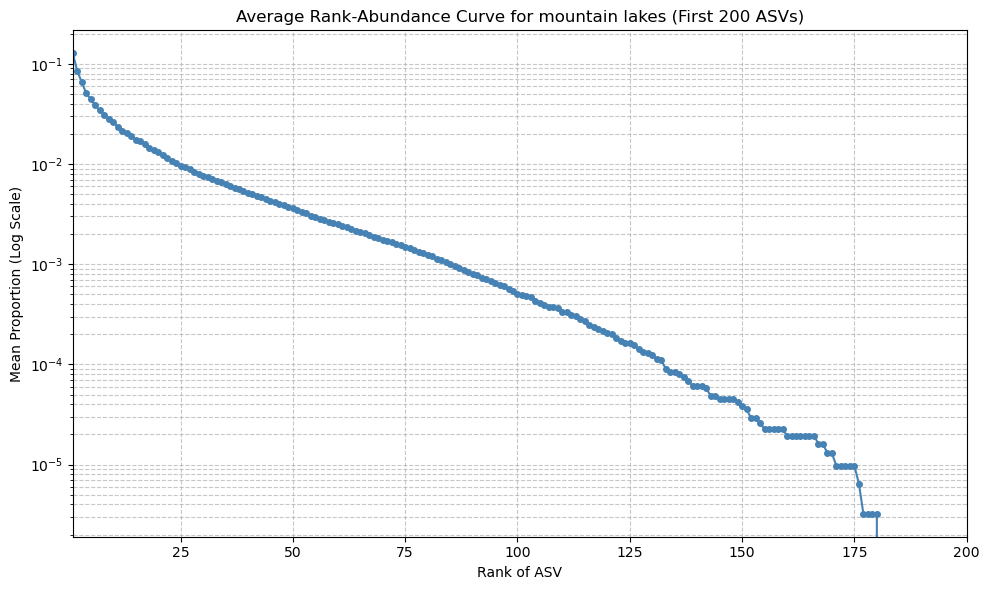

Plot generated for ranks 1 to 200.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)

# Keep only the first 32 columns (samples)
df = df.iloc[:, 0:32]

# Convert to numeric, coercing errors to NaN
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Dataframe is empty after cleaning.")

# 2. Data Processing
# A. Normalize to proportions
prop_df = df.div(df.sum(axis=0), axis=1)

# B. Sort each sample (column) independently
sorted_data = {}
max_rank = 0

for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

# C. Align data into a new DataFrame
aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)

for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

# D. Calculate mean for each rank
mean_abundance = aligned_df.mean(axis=1)

# 3. Plotting with ZOOM
# Define the cutoff rank
cutoff_rank = 200

# Slice the data to keep only the first 250 ranks
# Note: Python is 0-indexed, so [:250] gives us indices 0 to 249 (which corresponds to Ranks 1 to 250)
ranks_to_plot = np.arange(1, cutoff_rank + 1)
mean_to_plot = mean_abundance.iloc[:cutoff_rank]

# Check if we have enough data
if len(mean_to_plot) < cutoff_rank:
    print(f"Warning: Your data only has {len(mean_to_plot)} ranks. Plotting all available data.")
    cutoff_rank = len(mean_to_plot)
    ranks_to_plot = np.arange(1, cutoff_rank + 1)

plt.figure(figsize=(10, 6))

plt.plot(ranks_to_plot, mean_to_plot, marker='o', linestyle='-', color='steelblue', markersize=4)

plt.yscale('log')

# Set the X-axis limit explicitly to 250 (or max available if less)
plt.xlim(1, cutoff_rank)

plt.xlabel('Rank of ASV')
plt.ylabel('Mean Proportion (Log Scale)')
plt.title(f'Average Rank-Abundance Curve for mountain lakes (First {cutoff_rank} ASVs)')

plt.grid(True, which='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Plot generated for ranks 1 to {cutoff_rank}.")

Now with poster layout

<module 'matplotlib.pyplot' from '/Users/astr/Documents/Pigments/.conda/lib/python3.13/site-packages/matplotlib/pyplot.py'>

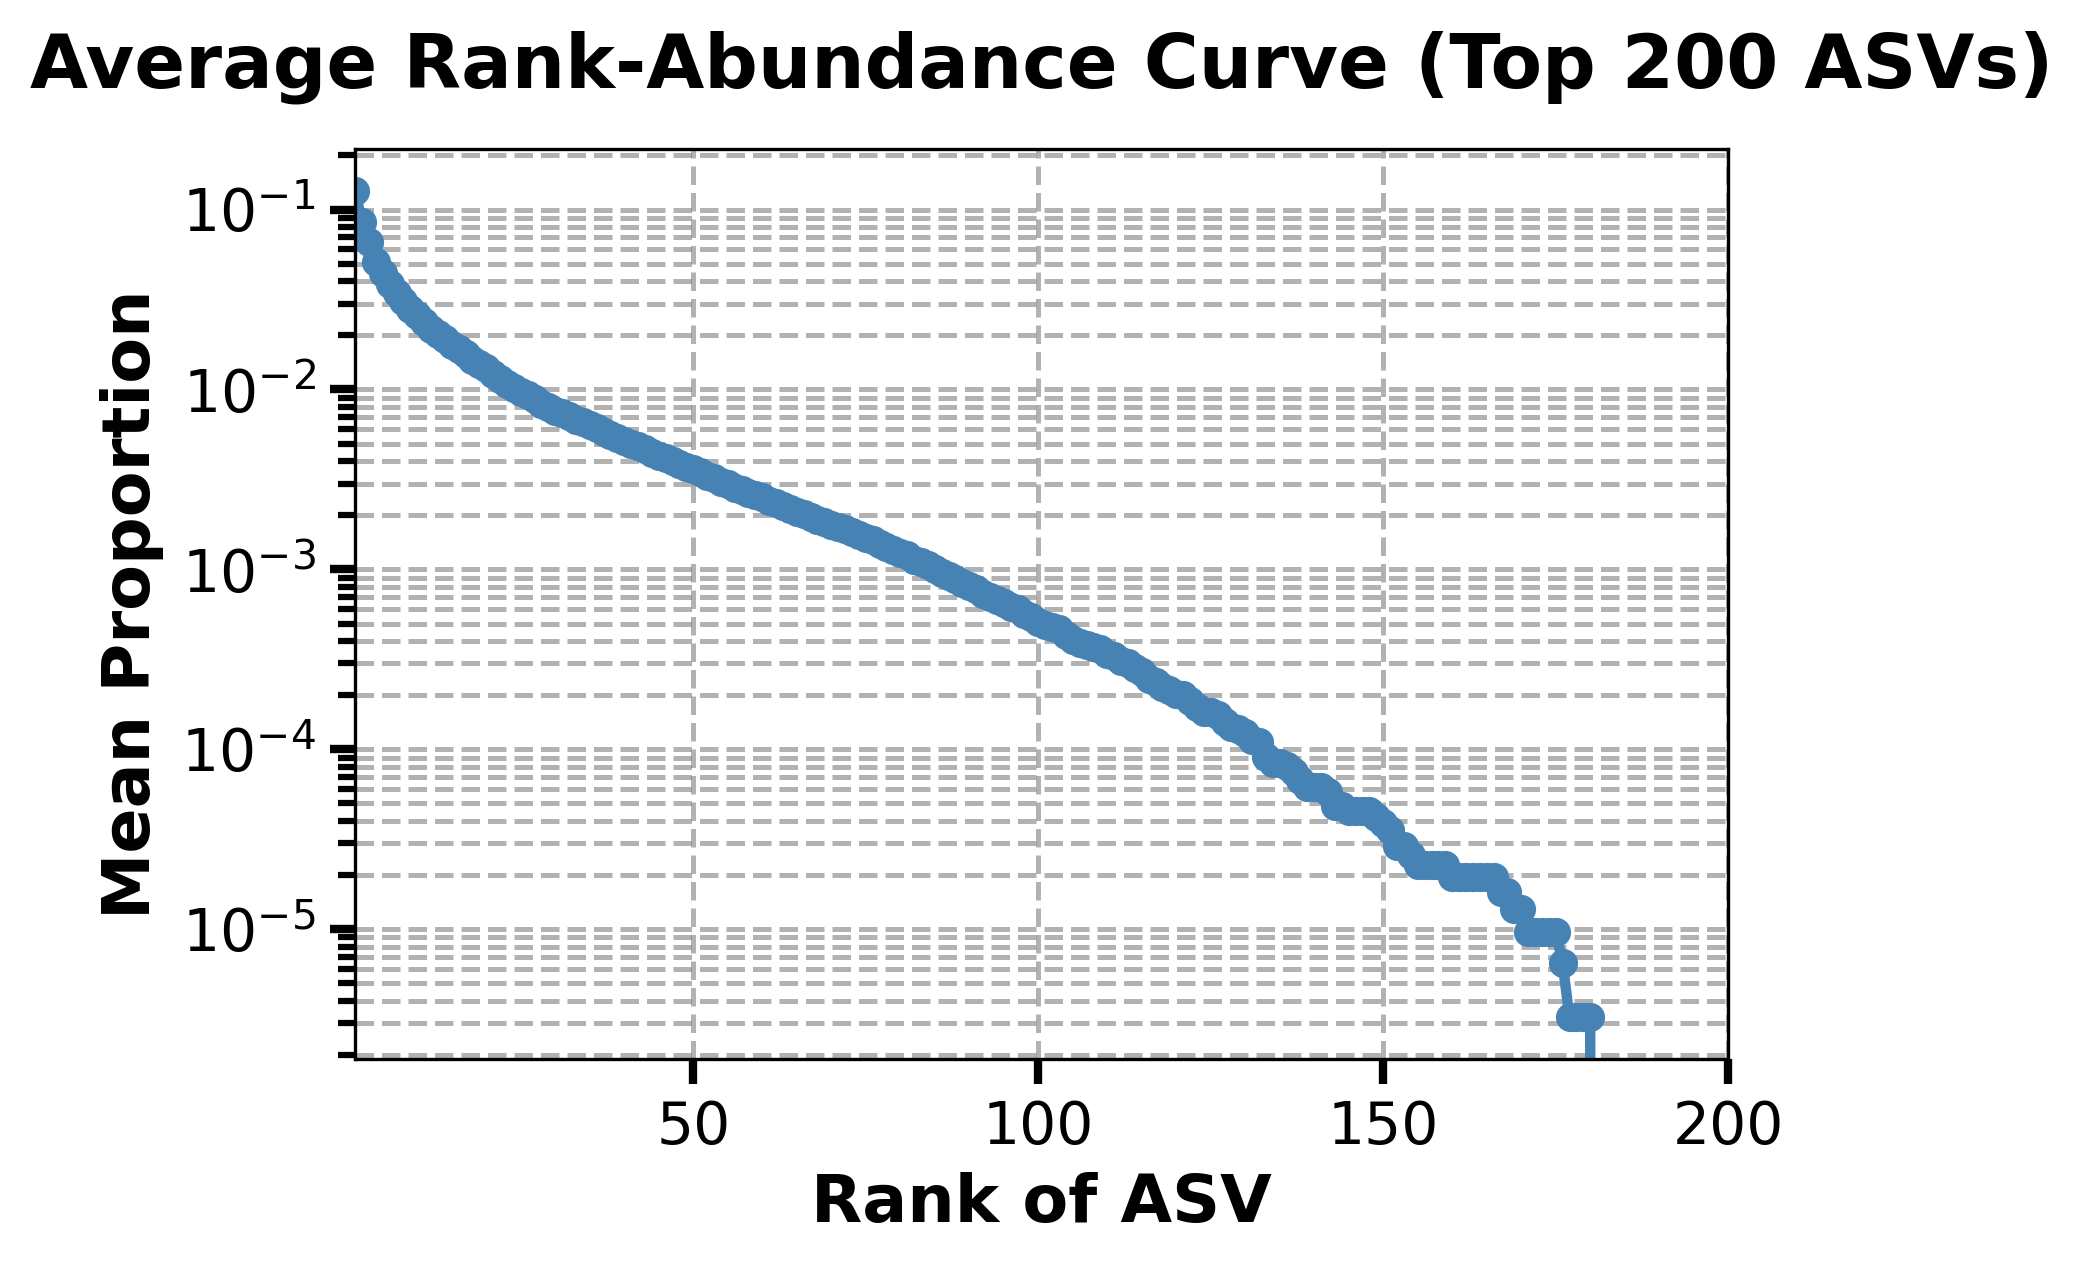

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION FOR POSTER ---
plot_width_cm = 15
plot_height_cm = 10  # Adjust height as needed (standard ~2:3 ratio)
dpi = 300            # High resolution for printing
cutoff_rank = 200    # Number of ranks to display
# ------------------------------

# Convert cm to inches (matplotlib uses inches)
fig_width_in = plot_width_cm / 2.54
fig_height_in = plot_height_cm / 2.54

# 1. Load and Clean Data
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)
df = df.iloc[:, 0:32]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Dataframe is empty.")

# 2. Data Processing
# Normalize
prop_df = df.div(df.sum(axis=0), axis=1)

# Sort and Align
sorted_data = {}
max_rank = 0
for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)
for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

mean_abundance = aligned_df.mean(axis=1)

# Slice data for the plot
ranks_to_plot = np.arange(1, min(cutoff_rank, len(mean_abundance)) + 1)
mean_to_plot = mean_abundance.iloc[:len(ranks_to_plot)]

actual_cutoff = len(ranks_to_plot)

# 3. Plotting for Poster
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)

# Plot with thicker lines and larger markers
ax.plot(ranks_to_plot, mean_to_plot, 
        marker='o', 
        linestyle='-', 
        color='steelblue', 
        linewidth=2.5,       # Thicker line for visibility
        markersize=6,        # Larger markers
        label='Mean Proportion')

# Log Scale
ax.set_yscale('log')

# Axis Limits
ax.set_xlim(1, actual_cutoff)

# --- BIG FONTS FOR POSTER ---
# Title
ax.set_title(f'Average Rank-Abundance Curve (Top {actual_cutoff} ASVs)', 
             fontsize=18, fontweight='bold', pad=15)

# X Label
ax.set_xlabel('Rank of ASV', 
              fontsize=16, fontweight='bold')

# Y Label
ax.set_ylabel('Mean Proportion', 
              fontsize=16, fontweight='bold')

# Tick Labels (The numbers on the axes)
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)
ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=4)

# Grid (Make it subtle but visible)
ax.grid(True, which='both', linestyle='--', linewidth=1.2, alpha=0.6, color='gray')

# Layout adjustment to prevent label cutoff
plt

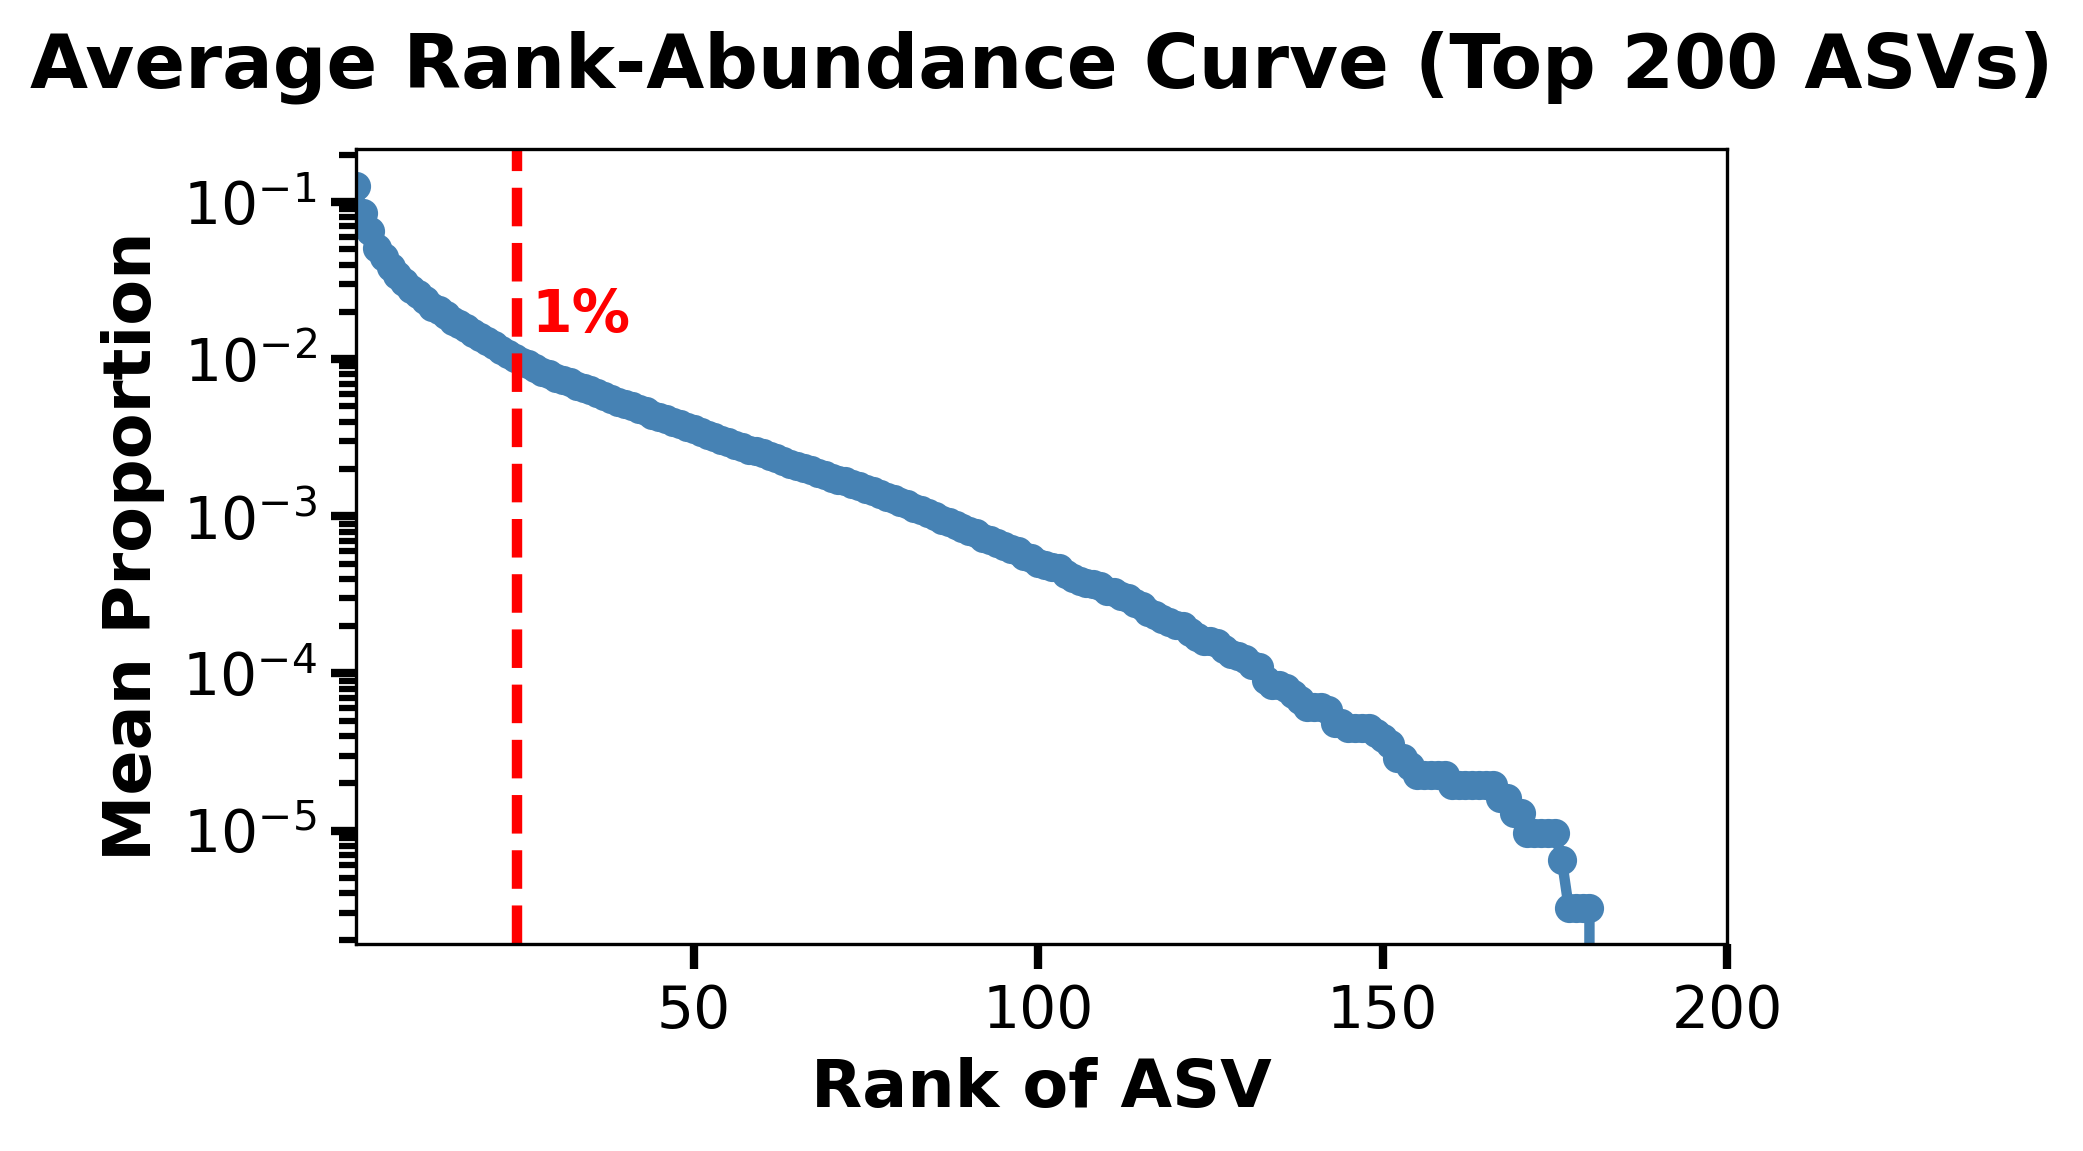

Plot saved as 'rank_abundance_poster_transparent_15cm.png' with transparent background.


<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION FOR POSTER ---
plot_width_cm = 15
plot_height_cm = 10
dpi = 300
cutoff_rank = 200
threshold_prop = 0.01  # The 1% threshold
# ------------------------------

# Convert cm to inches
fig_width_in = plot_width_cm / 2.54
fig_height_in = plot_height_cm / 2.54

# 1. Load and Clean Data
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)
df = df.iloc[:, 0:32]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Dataframe is empty.")

# 2. Data Processing
prop_df = df.div(df.sum(axis=0), axis=1)

sorted_data = {}
max_rank = 0
for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)
for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

mean_abundance = aligned_df.mean(axis=1)

# Slice data
ranks_to_plot = np.arange(1, min(cutoff_rank, len(mean_abundance)) + 1)
mean_to_plot = mean_abundance.iloc[:len(ranks_to_plot)]
actual_cutoff = len(ranks_to_plot)

# 3. Calculate Intersection for the Red Line
# We look for where the curve crosses threshold_prop (0.01)
# We need to find indices i where mean_to_plot[i] >= 0.01 and mean_to_plot[i+1] < 0.01
crossing_rank = None

# Convert to numpy for easier indexing
y_vals = mean_to_plot.values
x_vals = ranks_to_plot

for i in range(len(y_vals) - 1):
    if y_vals[i] >= threshold_prop and y_vals[i+1] < threshold_prop:
        # Linear interpolation to find exact x position
        # y = mx + b -> x = (y - b) / m
        # Slope m = (y2 - y1) / (x2 - x1)
        x1, x2 = x_vals[i], x_vals[i+1]
        y1, y2 = y_vals[i], y_vals[i+1]
        
        if y2 != y1: # Avoid division by zero
            slope = (y2 - y1) / (x2 - x1)
            crossing_rank = x1 + (threshold_prop - y1) / slope
        else:
            crossing_rank = x1
        break

# 4. Plotting
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)

ax.plot(x_vals, y_vals, 
        marker='o', 
        linestyle='-', 
        color='steelblue', 
        linewidth=2.5, 
        markersize=6, 
        label=f'Mean Proportion')

# Add the Red Vertical Line if the threshold is crossed within the plot range
if crossing_rank is not None:
    ax.axvline(x=crossing_rank, color='red', linestyle='--', linewidth=2.5, label=f'{threshold_prop*100:.0f}% Threshold')
    # Optional: Add a small text annotation near the line
    ax.text(crossing_rank + 2, threshold_prop * 1.5, f'{threshold_prop*100:.0f}%', color='red', fontsize=14, fontweight='bold')
else:
    print(f"Note: The proportion never drops to {threshold_prop} within the first {actual_cutoff} ranks.")

# Log Scale
ax.set_yscale('log')
ax.set_xlim(1, actual_cutoff)

# Labels & Fonts
ax.set_title(f'Average Rank-Abundance Curve (Top {actual_cutoff} ASVs)', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Rank of ASV', fontsize=16, fontweight='bold')
ax.set_ylabel('Mean Proportion', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)
ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=4)

# Grid
#ax.grid(True, which='both', linestyle='--', linewidth=1.0, alpha=0.6, color='gray')

# --- TRANSPARENT BACKGROUND ---
# This makes the background of the figure and the axes transparent
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

# Save with transparent background
output_filename = f'rank_abundance_poster_transparent_{plot_width_cm}cm.png'
plt.savefig(output_filename, dpi=dpi, bbox_inches='tight', facecolor='none', transparent=True)
print(f"Plot saved as '{output_filename}' with transparent background.")

### Adding sample curves

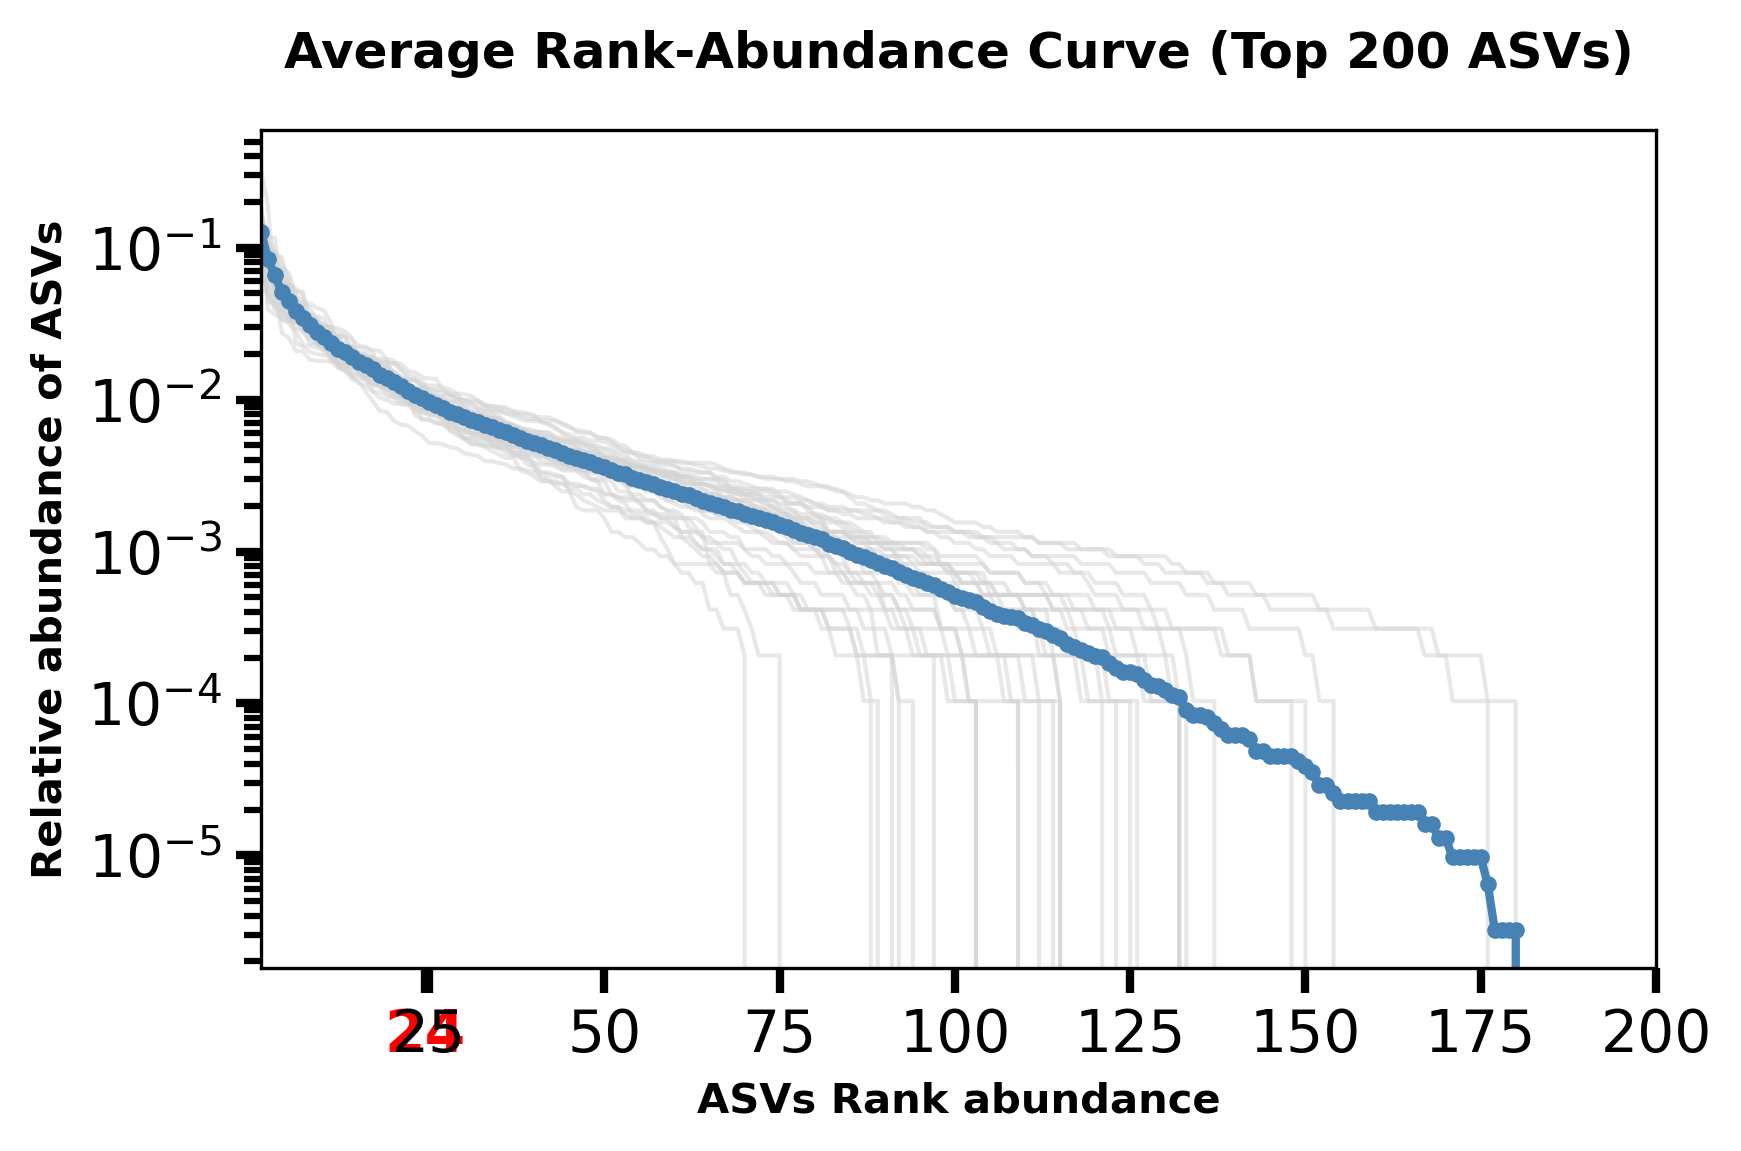

Plot saved as 'rank_abundance_poster_transparent_15cm.png' with transparent background.


<Figure size 640x480 with 0 Axes>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION FOR POSTER ---
plot_width_cm = 15
plot_height_cm = 10
dpi = 300
cutoff_rank = 200
threshold_prop = 0.01  # The 1% threshold
# ------------------------------

# Convert cm to inches
fig_width_in = plot_width_cm / 2.54
fig_height_in = plot_height_cm / 2.54

# 1. Load and Clean Data
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)
df = df.iloc[:, 0:32]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Dataframe is empty.")

# 2. Data Processing
prop_df = df.div(df.sum(axis=0), axis=1)

sorted_data = {}
max_rank = 0
for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)
for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

mean_abundance = aligned_df.mean(axis=1)

# Slice data
ranks_to_plot = np.arange(1, min(cutoff_rank, len(mean_abundance)) + 1)
mean_to_plot = mean_abundance.iloc[:len(ranks_to_plot)]
actual_cutoff = len(ranks_to_plot)

# Prepare individual sample data for plotting (sliced to same range)
individual_samples = aligned_df.iloc[:len(ranks_to_plot)]

# 3. Calculate Intersection for the Red Line
crossing_rank = None
y_vals = mean_to_plot.values
x_vals = ranks_to_plot

for i in range(len(y_vals) - 1):
    if y_vals[i] >= threshold_prop and y_vals[i+1] < threshold_prop:
        x1, x2 = x_vals[i], x_vals[i+1]
        y1, y2 = y_vals[i], y_vals[i+1]
        if y2 != y1:
            slope = (y2 - y1) / (x2 - x1)
            crossing_rank = x1 + (threshold_prop - y1) / slope
        else:
            crossing_rank = x1
        break

# 4. Plotting
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)

# --- Plot Individual Samples in Light Grey ---
for col in individual_samples.columns:
    ax.plot(x_vals, individual_samples[col], 
            color='lightgrey', 
            linewidth=1.0, 
            alpha=0.5, 
            label=None) # label=None prevents them from appearing in the legend

# Plot the Mean Curve (Blue, on top)
ax.plot(x_vals, y_vals, 
        marker='o', 
        linestyle='-', 
        color='steelblue', 
        linewidth=2, 
        markersize=3, 
        label=f'Mean Proportion')

# Add the Red Vertical Line
if crossing_rank is not None:
    # 1. Get default ticks and generate default labels as strings
    default_ticks = ax.get_xticks()
    # Filter out ticks that are outside our view limits (sometimes Matplotlib generates extra ones)
    default_ticks = [t for t in default_ticks if 1 <= t <= actual_cutoff]
    
    # 2. Create a new list of ticks including the crossing rank
    new_ticks = sorted(list(default_ticks) + [crossing_rank])
    
    # 3. Create corresponding labels
    new_labels = []
    for t in new_ticks:
        if abs(t - crossing_rank) < 0.01: # If this is our special tick
            # We create a Text object with red color directly, or just mark it for later
            # Simpler approach: Just store the value, we will colorize by index
            new_labels.append(str(int(np.round(t)))) # Store as string
        else:
            new_labels.append(str(int(np.round(t))))
            
    # 4. Set the ticks and labels
    ax.set_xticks(new_ticks)
    ax.set_xticklabels(new_labels)
    
    # 5. Now, colorize the specific label safely by index
    # Find the index of the crossing_rank in our new_ticks list
    try:
        idx = new_ticks.index(crossing_rank)
        # Get the list of label objects
        labels = ax.get_xticklabels()
        # Modify the specific one
        labels[idx].set_color('red')
        labels[idx].set_fontweight('bold')
        labels[idx].set_fontsize(16)
        # Re-apply the modified labels
        ax.set_xticklabels(labels)
    except ValueError:
        pass # Safety fallback if index not found

# Log Scale & Limits
ax.set_yscale('log')
ax.set_xlim(1, actual_cutoff)

# Labels & Fonts
ax.set_title(f'Average Rank-Abundance Curve (Top {actual_cutoff} ASVs)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('ASVs Rank abundance', fontsize=10, fontweight='bold')
ax.set_ylabel('Relative abundance of ASVs', fontsize=10, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)
ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=4)

# Transparent Background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

# Save
output_filename = f'rank_abundance_poster_transparent_{plot_width_cm}cm.png'
plt.savefig(output_filename, dpi=dpi, bbox_inches='tight', facecolor='none', transparent=True)
print(f"Plot saved as '{output_filename}' with transparent background.")

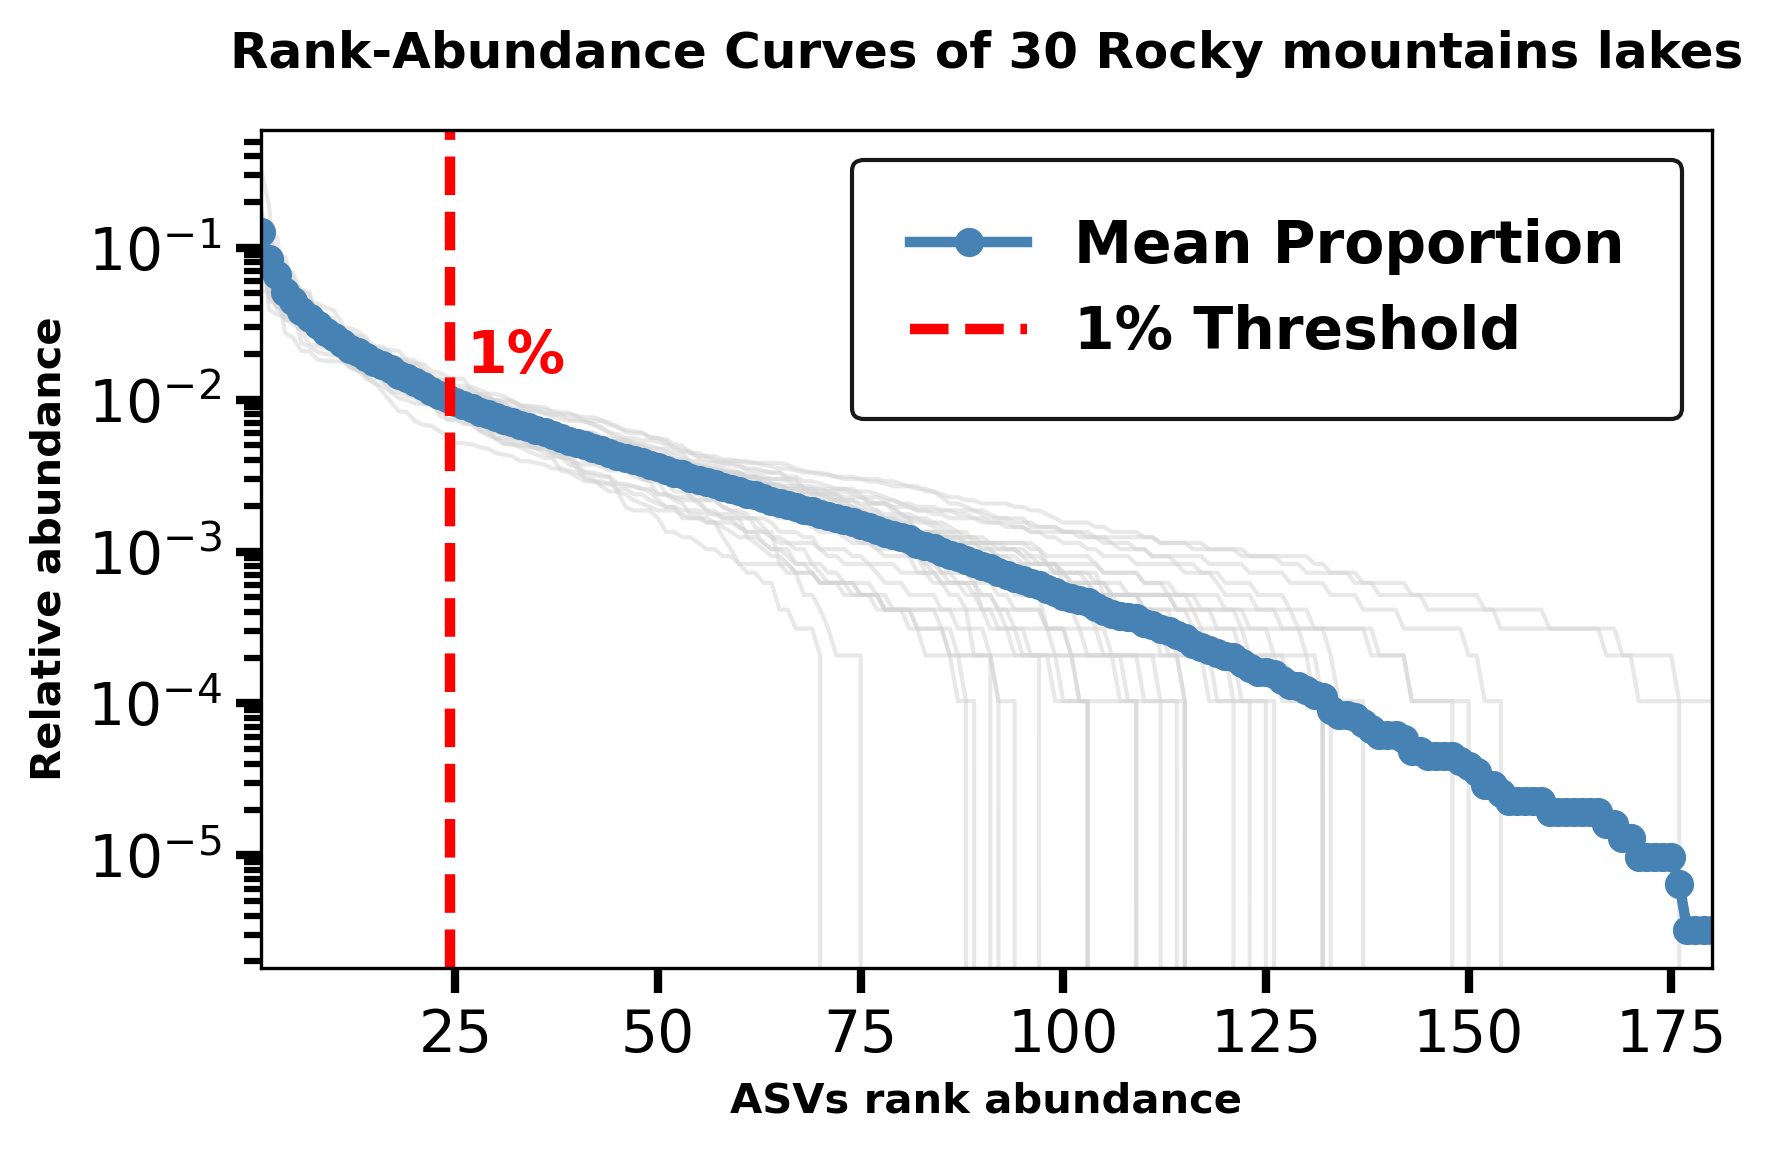

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION FOR POSTER ---
plot_width_cm = 15
plot_height_cm = 10
dpi = 300
cutoff_rank = 180
threshold_prop = 0.01  # The 1% threshold
# ------------------------------

# Convert cm to inches
fig_width_in = plot_width_cm / 2.54
fig_height_in = plot_height_cm / 2.54

# 1. Load and Clean Data
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)
df = df.iloc[:, 0:32]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Dataframe is empty.")

# 2. Data Processing
prop_df = df.div(df.sum(axis=0), axis=1)

sorted_data = {}
max_rank = 0
for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)
for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

mean_abundance = aligned_df.mean(axis=1)

# Slice data
ranks_to_plot = np.arange(1, min(cutoff_rank, len(mean_abundance)) + 1)
mean_to_plot = mean_abundance.iloc[:len(ranks_to_plot)]
actual_cutoff = len(ranks_to_plot)

# Prepare individual sample data
individual_samples = aligned_df.iloc[:len(ranks_to_plot)]

# 3. Calculate Intersection for the Red Line
crossing_rank = None
y_vals = mean_to_plot.values
x_vals = ranks_to_plot

for i in range(len(y_vals) - 1):
    if y_vals[i] >= threshold_prop and y_vals[i+1] < threshold_prop:
        x1, x2 = x_vals[i], x_vals[i+1]
        y1, y2 = y_vals[i], y_vals[i+1]
        if y2 != y1:
            slope = (y2 - y1) / (x2 - x1)
            crossing_rank = x1 + (threshold_prop - y1) / slope
        else:
            crossing_rank = x1
        break

# 4. Plotting
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)

# Plot Individual Samples (Grey)
for col in individual_samples.columns:
    ax.plot(x_vals, individual_samples[col], 
            color='lightgrey', linewidth=1.0, alpha=0.5, label=None)

# Plot Mean Curve (Blue)
ax.plot(x_vals, y_vals, 
        marker='o', linestyle='-', color='steelblue', 
        linewidth=2.5, markersize=6, label=f'Mean Proportion')

# --- RESTORED: Vertical Line, Text, and Red X-Axis Label ---
if crossing_rank is not None:
    # A. Draw the vertical line
    ax.axvline(x=crossing_rank, color='red', linestyle='--', linewidth=2.5, label=f'{threshold_prop*100:.0f}% Threshold')
    
    # B. Add the text annotation
    ax.text(crossing_rank + 2, threshold_prop * 1.5, f'{threshold_prop*100:.0f}%', color='red', fontsize=14, fontweight='bold')
    
    # C. Add the red tick label on X-axis (Robust Method)
    # 1. Get default ticks within limits
    #default_ticks = [t for t in ax.get_xticks() if 1 <= t <= actual_cutoff]
    
    # 2. Add crossing_rank and sort
    #new_ticks = sorted(list(default_ticks) + [crossing_rank])
    
    # 3. Create clean string labels for all ticks
    #new_labels = [str(int(np.round(t))) for t in new_ticks]
    
    # 4. Apply ticks and labels
    #ax.set_xticks(new_ticks)
    #ax.set_xticklabels(new_labels)
    
    # 5. Colorize the specific label by index
    #try:
    #    idx = new_ticks.index(crossing_rank)
    #    labels = ax.get_xticklabels()
    #    labels[idx].set_color('red')
    #    labels[idx].set_fontweight('bold')
    #    labels[idx].set_fontsize(16)
    #    ax.set_xticklabels(labels) # Re-apply to confirm changes
    #except ValueError:
    #    pass # Fallback if index not found
# -----------------------------------------------------------

# Log Scale & Limits
ax.set_yscale('log')
ax.set_xlim(1, actual_cutoff)

# Labels & Fonts
ax.set_title(f'Rank-Abundance Curves of 30 Rocky mountains lakes', fontsize=12, fontweight='bold', pad=15) #(Top {actual_cutoff} ASVs)
ax.set_xlabel('ASVs rank abundance', fontsize=10, fontweight='bold')
ax.set_ylabel('Relative abundance', fontsize=10, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)
ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=4)

# --- ADD LEGEND (Top Right) ---
leg = ax.legend(
    loc='upper right',          # Position: Top Right
    prop={'size': 14, 'weight': 'bold'}, # Bold, large font
    frameon=True,               # Show box
    framealpha=0.9,             # Slightly transparent background
    edgecolor='black',          # Black border
    borderpad=1                 # Padding inside box
)

# Transparent Background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

# Save
#output_filename = f'rank_abundance_poster_transparent_{plot_width_cm}cm.png'
#plt.savefig(output_filename, dpi=dpi, bbox_inches='tight', facecolor='none', transparent=True)
#print(f"Plot saved as '{output_filename}' with transparent background.")

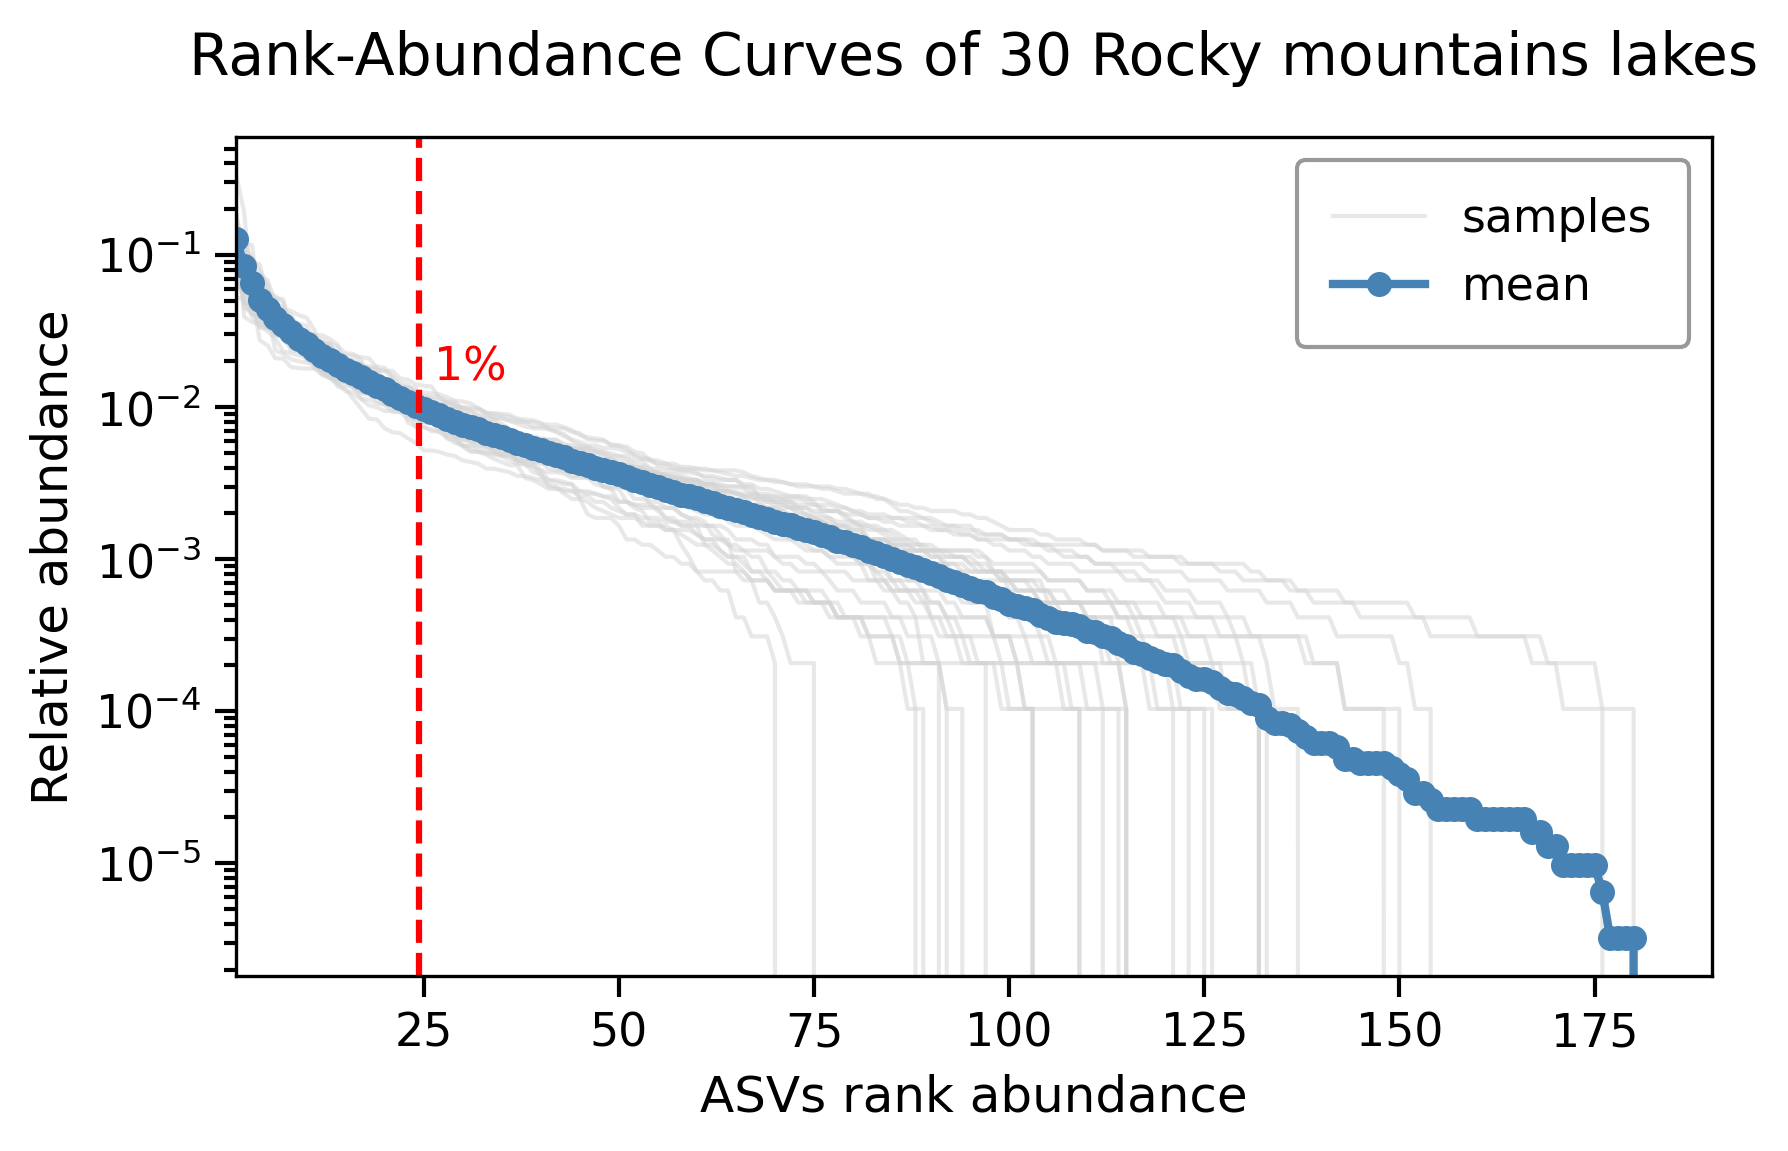

Plot saved as 'rank_abundance_report_15cm.png' for report.


<Figure size 640x480 with 0 Axes>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION FOR REPORT ---
plot_width_cm = 15
plot_height_cm = 10
dpi = 300            # Keep high DPI for good print quality in reports
cutoff_rank = 190
threshold_prop = 0.01
# ------------------------------

# Convert cm to inches
fig_width_in = plot_width_cm / 2.54
fig_height_in = plot_height_cm / 2.54

# 1. Load and Clean Data
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)
df = df.iloc[:, 0:32]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Dataframe is empty.")

# 2. Data Processing
prop_df = df.div(df.sum(axis=0), axis=1)

sorted_data = {}
max_rank = 0
for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)
for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

mean_abundance = aligned_df.mean(axis=1)

# Slice data
ranks_to_plot = np.arange(1, min(cutoff_rank, len(mean_abundance)) + 1)
mean_to_plot = mean_abundance.iloc[:len(ranks_to_plot)]
actual_cutoff = len(ranks_to_plot)

# Prepare individual sample data
individual_samples = aligned_df.iloc[:len(ranks_to_plot)]

# 3. Calculate Intersection for the Red Line
crossing_rank = None
y_vals = mean_to_plot.values
x_vals = ranks_to_plot

for i in range(len(y_vals) - 1):
    if y_vals[i] >= threshold_prop and y_vals[i+1] < threshold_prop:
        x1, x2 = x_vals[i], x_vals[i+1]
        y1, y2 = y_vals[i], y_vals[i+1]
        if y2 != y1:
            slope = (y2 - y1) / (x2 - x1)
            crossing_rank = x1 + (threshold_prop - y1) / slope
        else:
            crossing_rank = x1
        break

# 4. Plotting
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)

# --- PLOT INDIVIDUAL SAMPLES (GREY) ---
first_sample = True
for col in individual_samples.columns:
    if first_sample:
        ax.plot(x_vals, individual_samples[col], 
                color='lightgrey', linewidth=1.0, alpha=0.5, label='samples')
        first_sample = False
    else:
        ax.plot(x_vals, individual_samples[col], 
                color='lightgrey', linewidth=1.0, alpha=0.5, label=None)

# --- PLOT MEAN CURVE (BLUE) ---
ax.plot(x_vals, y_vals, 
        marker='o', linestyle='-', color='steelblue', 
        linewidth=2.0, markersize=5, label='mean') # Slightly thinner lines for report

# --- VERTICAL LINE & ANNOTATION (No Legend) ---
if crossing_rank is not None:
    # label=None ensures it does NOT appear in the legend
    ax.axvline(x=crossing_rank, color='red', linestyle='--', linewidth=1.5, label=None)
    ax.text(crossing_rank + 2, threshold_prop * 1.5, f'{threshold_prop*100:.0f}%', color='red', fontsize=11)


# Log Scale & Limits
ax.set_yscale('log')
ax.set_xlim(1, actual_cutoff)

# Labels & Fonts (Standard Report Style)
ax.set_title(f'Rank-Abundance Curves of 30 Rocky mountains lakes', fontsize=14, fontweight='normal', pad=15)
ax.set_xlabel('ASVs rank abundance', fontsize=12, fontweight='normal')
ax.set_ylabel('Relative abundance', fontsize=12, fontweight='normal')
ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=5)
ax.tick_params(axis='both', which='minor', labelsize=10, width=1, length=3)

# --- ADD LEGEND (Top Right, Standard Style) ---
leg = ax.legend(
    loc='upper right',
    prop={'size': 11, 'weight': 'normal'}, # Normal weight, smaller size
    frameon=True,
    framealpha=0.8,
    edgecolor='gray',
    borderpad=0.8
)
leg.get_frame().set_linewidth(1.0) # Thinner border

# Transparent Background (Good for inserting into Word/LaTeX)
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

# Save
output_filename = f'rank_abundance_report_{plot_width_cm}cm.png'
plt.savefig(output_filename, dpi=dpi, bbox_inches='tight', facecolor='none', transparent=True)
print(f"Plot saved as '{output_filename}' for report.")

# Adding Léman data

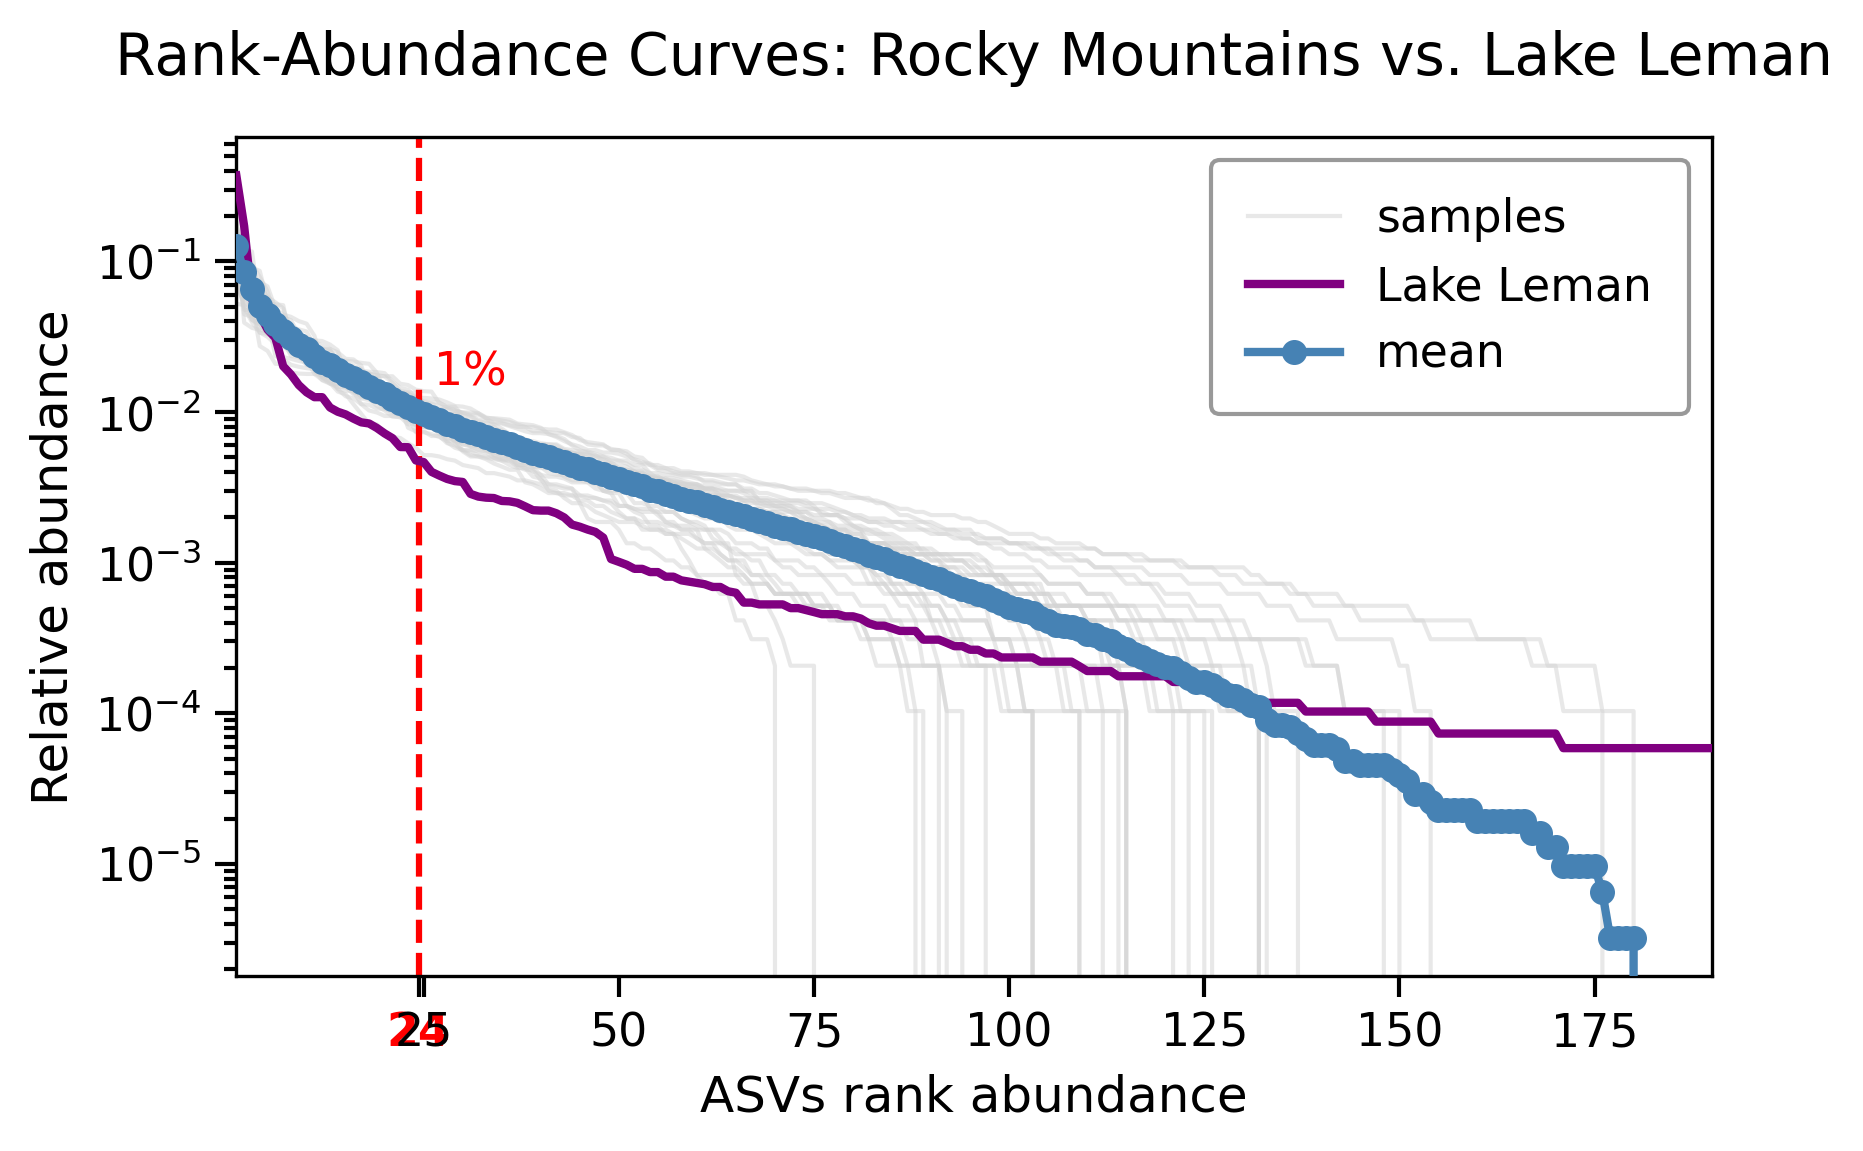

Plot saved as 'rank_abundance_report_with_leman_15cm.png' for report.


<Figure size 640x480 with 0 Axes>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION FOR REPORT ---
plot_width_cm = 15
plot_height_cm = 10
dpi = 300
cutoff_rank = 190
threshold_prop = 0.01
# ------------------------------

# Convert cm to inches
fig_width_in = plot_width_cm / 2.54
fig_height_in = plot_height_cm / 2.54

# 1. Load and Clean Main Data (Rocky Mountains)
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)
df = df.iloc[:, 0:32]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Main dataframe is empty.")

# 2. Process Main Data
prop_df = df.div(df.sum(axis=0), axis=1)

sorted_data = {}
max_rank = 0
for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)
for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

mean_abundance = aligned_df.mean(axis=1)

# Slice main data
ranks_to_plot = np.arange(1, min(cutoff_rank, len(mean_abundance)) + 1)
mean_to_plot = mean_abundance.iloc[:len(ranks_to_plot)]
actual_cutoff = len(ranks_to_plot)
individual_samples = aligned_df.iloc[:len(ranks_to_plot)]

# 3. Load and Process Lake Leman Data (Excel)
# Ensure you have 'openpyxl' installed: pip install openpyxl
try:
    df_leman = pd.read_csv('Bias_Leman_16S.csv', sep=';')
    
    # Check if column exists
    if 'LemanWC16' not in df_leman.columns:
        raise ValueError("Column 'LemanWC16' not found in Excel file.")
    
    # Extract counts
    leman_counts = df_leman['LemanWC16'].apply(pd.to_numeric, errors='coerce').dropna()
    
    # Convert to proportions
    leman_prop = leman_counts / leman_counts.sum()
    
    # Sort descending (Rank 1 is most abundant)
    leman_sorted = leman_prop.sort_values(ascending=False).values
    
    # Slice to match the plot's X-axis limit (cutoff_rank)
    leman_to_plot = leman_sorted[:len(ranks_to_plot)]
    
    # Pad with NaN if Leman has fewer ASVs than the cutoff (prevents crashing)
    if len(leman_to_plot) < len(ranks_to_plot):
        leman_to_plot = np.pad(leman_to_plot, (0, len(ranks_to_plot) - len(leman_to_plot)), constant_values=np.nan)
        
    leman_plotted = True

except Exception as e:
    print(f"Warning: Could not load Lake Leman data. Error: {e}")
    leman_plotted = False

# 4. Calculate Intersection for the Red Line (Based on Main Mean)
crossing_rank = None
y_vals = mean_to_plot.values
x_vals = ranks_to_plot

for i in range(len(y_vals) - 1):
    if y_vals[i] >= threshold_prop and y_vals[i+1] < threshold_prop:
        x1, x2 = x_vals[i], x_vals[i+1]
        y1, y2 = y_vals[i], y_vals[i+1]
        if y2 != y1:
            slope = (y2 - y1) / (x2 - x1)
            crossing_rank = x1 + (threshold_prop - y1) / slope
        else:
            crossing_rank = x1
        break

# 5. Plotting
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)

# --- PLOT INDIVIDUAL SAMPLES (GREY) ---
first_sample = True
for col in individual_samples.columns:
    if first_sample:
        ax.plot(x_vals, individual_samples[col], 
                color='lightgrey', linewidth=1.0, alpha=0.5, label='samples')
        first_sample = False
    else:
        ax.plot(x_vals, individual_samples[col], 
                color='lightgrey', linewidth=1.0, alpha=0.5, label=None)

# --- PLOT LAKE LEMAN (PURPLE) ---
if leman_plotted:
    ax.plot(x_vals, leman_to_plot, 
            color='purple', linestyle='-', linewidth=2.0, markersize=0, # No markers for clean line
            label='Lake Leman', zorder=10) # zorder ensures it draws on top of grey lines

# --- PLOT MEAN CURVE (BLUE) ---
ax.plot(x_vals, y_vals, 
        marker='o', linestyle='-', color='steelblue', 
        linewidth=2.0, markersize=5, label='mean', zorder=11) # Highest zorder

# --- VERTICAL LINE & ANNOTATION ---
if crossing_rank is not None:
    ax.axvline(x=crossing_rank, color='red', linestyle='--', linewidth=1.5, label=None)
    ax.text(crossing_rank + 2, threshold_prop * 1.5, f'{threshold_prop*100:.0f}%', color='red', fontsize=11)
    
    # Red X-Axis Label Logic
    default_ticks = [t for t in ax.get_xticks() if 1 <= t <= actual_cutoff]
    new_ticks = sorted(list(default_ticks) + [crossing_rank])
    new_labels = [str(int(np.round(t))) for t in new_ticks]
    
    ax.set_xticks(new_ticks)
    ax.set_xticklabels(new_labels)
    
    try:
        idx = new_ticks.index(crossing_rank)
        labels = ax.get_xticklabels()
        labels[idx].set_color('red')
        labels[idx].set_fontweight('bold')
        labels[idx].set_fontsize(12)
        ax.set_xticklabels(labels)
    except ValueError:
        pass

# Log Scale & Limits
ax.set_yscale('log')
ax.set_xlim(1, actual_cutoff)

# Labels & Fonts
ax.set_title(f'Rank-Abundance Curves: Rocky Mountains vs. Lake Leman', fontsize=14, fontweight='normal', pad=15)
ax.set_xlabel('ASVs rank abundance', fontsize=12, fontweight='normal')
ax.set_ylabel('Relative abundance', fontsize=12, fontweight='normal')
ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=5)
ax.tick_params(axis='both', which='minor', labelsize=10, width=1, length=3)

# --- ADD LEGEND ---
leg = ax.legend(
    loc='upper right',
    prop={'size': 11, 'weight': 'normal'},
    frameon=True,
    framealpha=0.8,
    edgecolor='gray',
    borderpad=0.8
)
leg.get_frame().set_linewidth(1.0)

# Transparent Background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

# Save
output_filename = f'rank_abundance_report_with_leman_{plot_width_cm}cm.png'
plt.savefig(output_filename, dpi=dpi, bbox_inches='tight', facecolor='none', transparent=True)
print(f"Plot saved as '{output_filename}' for report.")

Great, now we want to focus on the 50 first species.

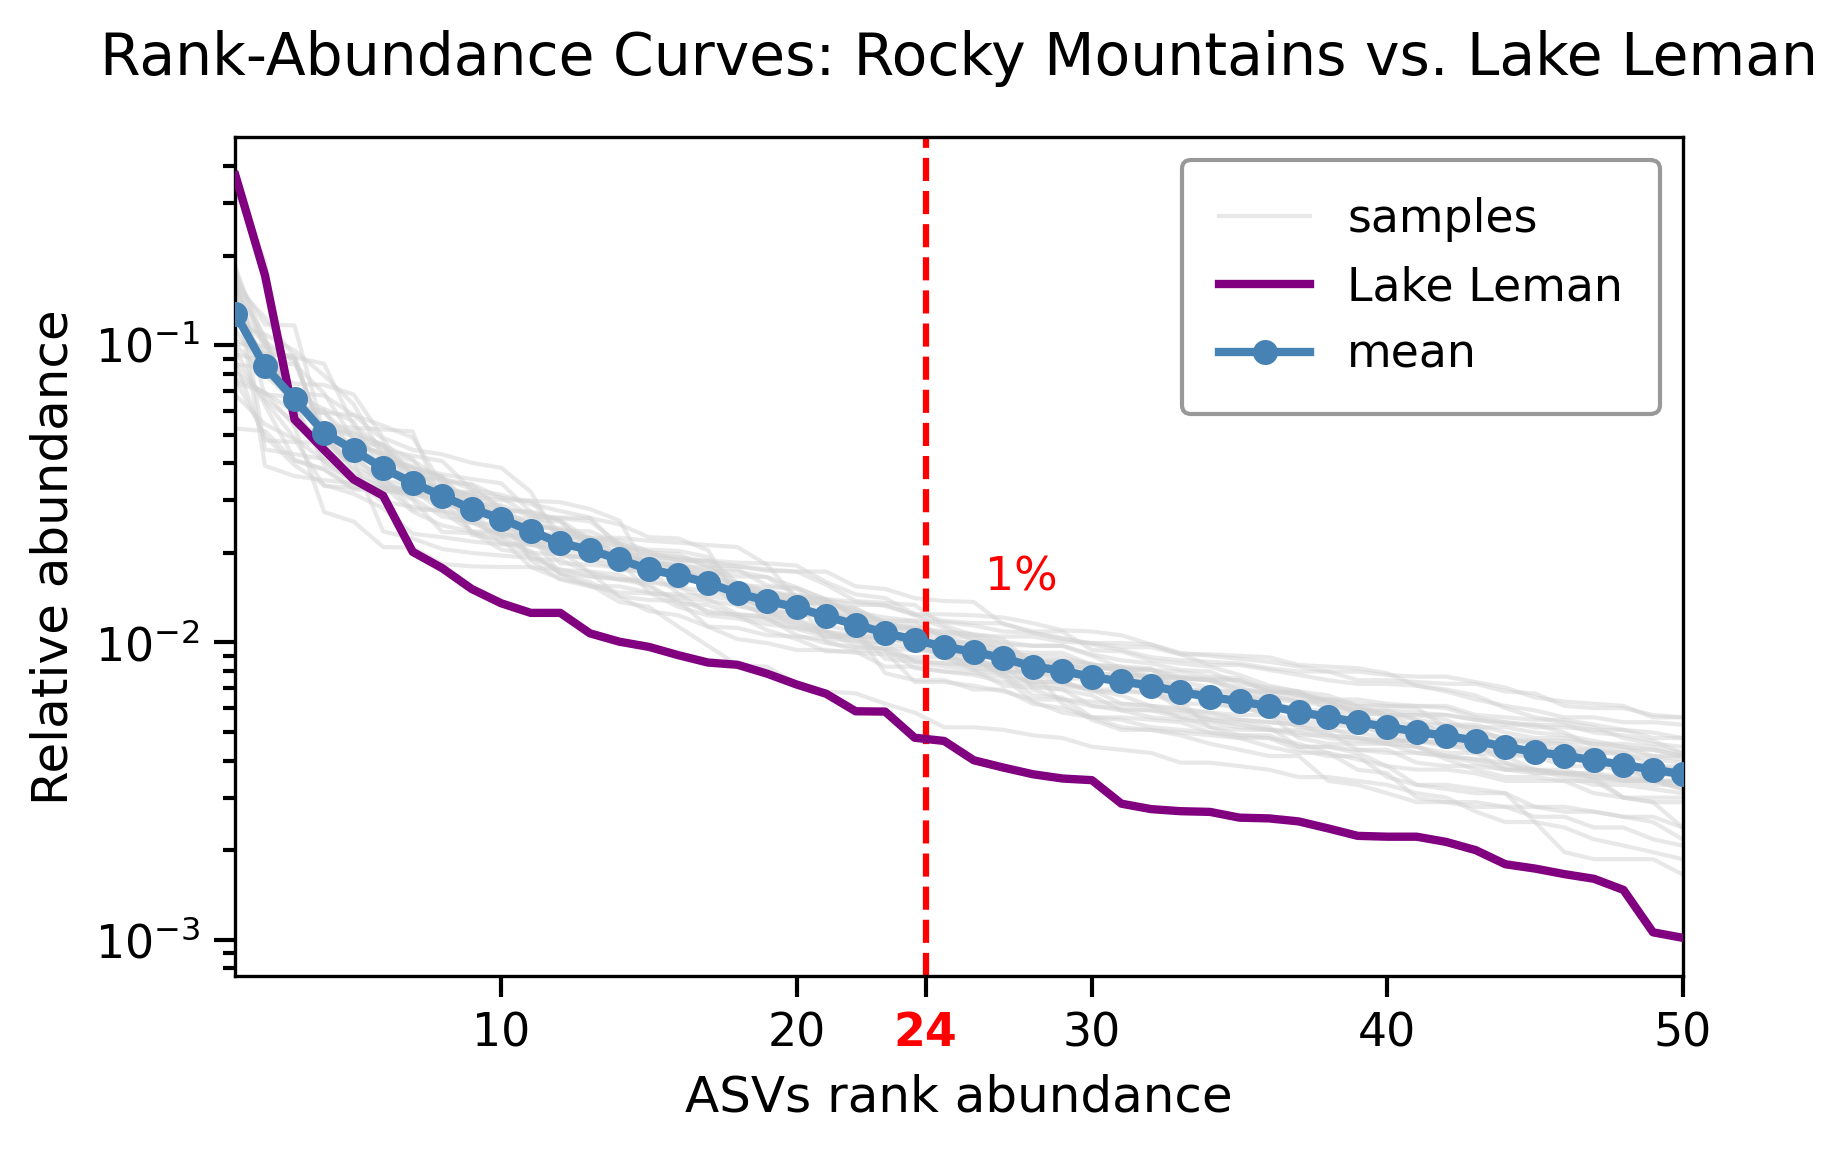

Plot saved as 'rank_abundance_report_with_leman_15cm.png' for report.


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION FOR REPORT ---
plot_width_cm = 15
plot_height_cm = 10
dpi = 300
cutoff_rank = 50
threshold_prop = 0.01
# ------------------------------

# Convert cm to inches
fig_width_in = plot_width_cm / 2.54
fig_height_in = plot_height_cm / 2.54

# 1. Load and Clean Main Data (Rocky Mountains)
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)
df = df.iloc[:, 0:32]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Main dataframe is empty.")

# 2. Process Main Data
prop_df = df.div(df.sum(axis=0), axis=1)

sorted_data = {}
max_rank = 0
for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)
for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

mean_abundance = aligned_df.mean(axis=1)

# Slice main data
ranks_to_plot = np.arange(1, min(cutoff_rank, len(mean_abundance)) + 1)
mean_to_plot = mean_abundance.iloc[:len(ranks_to_plot)]
actual_cutoff = len(ranks_to_plot)
individual_samples = aligned_df.iloc[:len(ranks_to_plot)]

# 3. Load and Process Lake Leman Data (Excel)
# Ensure you have 'openpyxl' installed: pip install openpyxl
try:
    df_leman = pd.read_csv('Bias_Leman_16S.csv', sep=';')
    df_leman2 = pd.read_csv('Ezzeline et al 2020.csv', sep=';')
    
    # Check if column exists
    if 'LemanWC16' not in df_leman.columns:
        raise ValueError("Column 'LemanWC16' not found in Excel file.")
    
    # Extract counts
    leman_counts = df_leman['LemanWC16'].apply(pd.to_numeric, errors='coerce').dropna()
    leman_counts2 = df_leman['LemanWC16'].apply(pd.to_numeric, errors='coerce').dropna()
    
    # Convert to proportions
    leman_prop = leman_counts / leman_counts.sum()
    
    # Sort descending (Rank 1 is most abundant)
    leman_sorted = leman_prop.sort_values(ascending=False).values
    
    # Slice to match the plot's X-axis limit (cutoff_rank)
    leman_to_plot = leman_sorted[:len(ranks_to_plot)]
    
    # Pad with NaN if Leman has fewer ASVs than the cutoff (prevents crashing)
    if len(leman_to_plot) < len(ranks_to_plot):
        leman_to_plot = np.pad(leman_to_plot, (0, len(ranks_to_plot) - len(leman_to_plot)), constant_values=np.nan)
        
    leman_plotted = True

except Exception as e:
    print(f"Warning: Could not load Lake Leman data. Error: {e}")
    leman_plotted = False

# 4. Calculate Intersection for the Red Line (Based on Main Mean)
crossing_rank = None
y_vals = mean_to_plot.values
x_vals = ranks_to_plot

for i in range(len(y_vals) - 1):
    if y_vals[i] >= threshold_prop and y_vals[i+1] < threshold_prop:
        x1, x2 = x_vals[i], x_vals[i+1]
        y1, y2 = y_vals[i], y_vals[i+1]
        if y2 != y1:
            slope = (y2 - y1) / (x2 - x1)
            crossing_rank = x1 + (threshold_prop - y1) / slope
        else:
            crossing_rank = x1
        break

# 5. Plotting
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)

# --- PLOT INDIVIDUAL SAMPLES (GREY) ---
first_sample = True
for col in individual_samples.columns:
    if first_sample:
        ax.plot(x_vals, individual_samples[col], 
                color='lightgrey', linewidth=1.0, alpha=0.5, label='samples')
        first_sample = False
    else:
        ax.plot(x_vals, individual_samples[col], 
                color='lightgrey', linewidth=1.0, alpha=0.5, label=None)

# --- PLOT LAKE LEMAN (PURPLE) ---
if leman_plotted:
    ax.plot(x_vals, leman_to_plot, 
            color='purple', linestyle='-', linewidth=2.0, markersize=0, # No markers for clean line
            label='Lake Leman', zorder=10) # zorder ensures it draws on top of grey lines

# --- PLOT MEAN CURVE (BLUE) ---
ax.plot(x_vals, y_vals, 
        marker='o', linestyle='-', color='steelblue', 
        linewidth=2.0, markersize=5, label='mean', zorder=11) # Highest zorder

# --- VERTICAL LINE & ANNOTATION ---
if crossing_rank is not None:
    ax.axvline(x=crossing_rank, color='red', linestyle='--', linewidth=1.5, label=None)
    ax.text(crossing_rank + 2, threshold_prop * 1.5, f'{threshold_prop*100:.0f}%', color='red', fontsize=11)
    
    # Red X-Axis Label Logic
    default_ticks = [t for t in ax.get_xticks() if 1 <= t <= actual_cutoff]
    new_ticks = sorted(list(default_ticks) + [crossing_rank])
    new_labels = [str(int(np.round(t))) for t in new_ticks]
    
    ax.set_xticks(new_ticks)
    ax.set_xticklabels(new_labels)
    
    try:
        idx = new_ticks.index(crossing_rank)
        labels = ax.get_xticklabels()
        labels[idx].set_color('red')
        labels[idx].set_fontweight('bold')
        labels[idx].set_fontsize(12)
        ax.set_xticklabels(labels)
    except ValueError:
        pass

# Log Scale & Limits
ax.set_yscale('log')
ax.set_xlim(1, actual_cutoff)

# Labels & Fonts
ax.set_title(f'Rank-Abundance Curves: Rocky Mountains vs. Lake Leman', fontsize=14, fontweight='normal', pad=15)
ax.set_xlabel('ASVs rank abundance', fontsize=12, fontweight='normal')
ax.set_ylabel('Relative abundance', fontsize=12, fontweight='normal')
ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=5)
ax.tick_params(axis='both', which='minor', labelsize=10, width=1, length=3)

# --- ADD LEGEND ---
leg = ax.legend(
    loc='upper right',
    prop={'size': 11, 'weight': 'normal'},
    frameon=True,
    framealpha=0.8,
    edgecolor='gray',
    borderpad=0.8
)
leg.get_frame().set_linewidth(1.0)

# Transparent Background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

# Save
output_filename = f'rank_abundance_report_with_leman_{plot_width_cm}cm.png'
plt.savefig(output_filename, dpi=dpi, bbox_inches='tight', facecolor='none', transparent=True)
print(f"Plot saved as '{output_filename}' for report.")

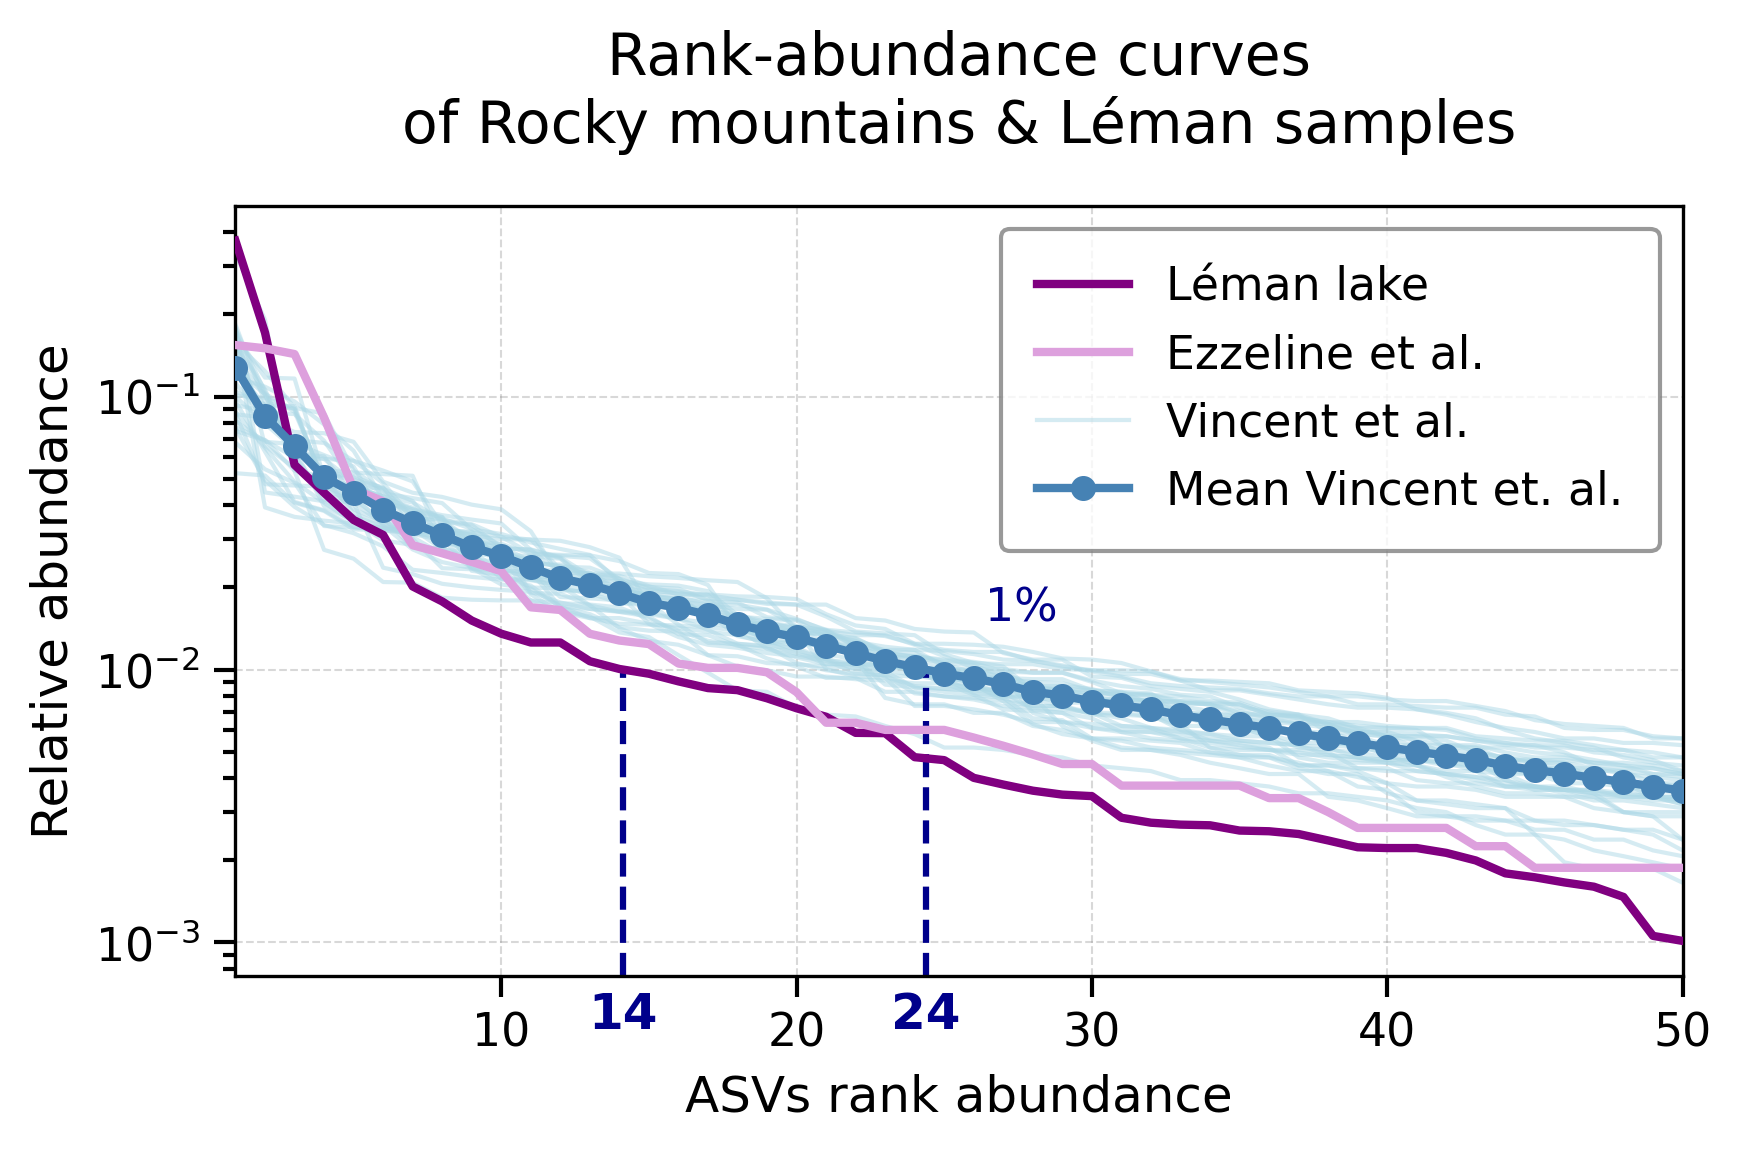

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
import numpy as np

# --- CONFIGURATION FOR REPORT ---
plot_width_cm = 15
plot_height_cm = 10
dpi = 300
cutoff_rank = 50
threshold_prop = 0.01
# ------------------------------

# Convert cm to inches
fig_width_in = plot_width_cm / 2.54
fig_height_in = plot_height_cm / 2.54

# 1. Load and Clean Main Data (Rocky Mountains)
df = pd.read_csv('Seq_Table_Bac_wtaxa.csv', index_col=0)
df = df.iloc[:, 0:32]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(how='all')

if df.empty:
    raise ValueError("Main dataframe is empty.")

# 2. Process Main Data
prop_df = df.div(df.sum(axis=0), axis=1)

sorted_data = {}
max_rank = 0
for col in prop_df.columns:
    sorted_vals = prop_df[col].dropna().sort_values(ascending=False).values
    sorted_data[col] = sorted_vals
    if len(sorted_vals) > max_rank:
        max_rank = len(sorted_vals)

aligned_df = pd.DataFrame(index=range(max_rank), columns=prop_df.columns)
for col, values in sorted_data.items():
    aligned_df[col] = pd.Series(values)

mean_abundance = aligned_df.mean(axis=1)

# Slice main data
ranks_to_plot = np.arange(1, min(cutoff_rank, len(mean_abundance)) + 1)
mean_to_plot = mean_abundance.iloc[:len(ranks_to_plot)]
actual_cutoff = len(ranks_to_plot)
individual_samples = aligned_df.iloc[:len(ranks_to_plot)]

# 3. Load and Process External Data
# Load Lake Leman
df_leman = pd.read_csv('Bias_Leman_16S.csv', sep=';')
leman_counts = df_leman['LemanWC16'].apply(pd.to_numeric, errors='coerce').dropna()
leman_prop = leman_counts / leman_counts.sum()
leman_sorted = leman_prop.sort_values(ascending=False).values
leman_to_plot = leman_sorted[:len(ranks_to_plot)]
if len(leman_to_plot) < len(ranks_to_plot):
    leman_to_plot = np.pad(leman_to_plot, (0, len(ranks_to_plot) - len(leman_to_plot)), constant_values=np.nan)

# Load Ezzeline et al 2020
df_ezz = pd.read_csv('Ezzeline et al 2020.csv', sep=';')
ezz_counts = df_ezz['counts'].apply(pd.to_numeric, errors='coerce').dropna()
ezz_prop = ezz_counts / ezz_counts.sum()
ezz_sorted = ezz_prop.sort_values(ascending=False).values
ezz_to_plot = ezz_sorted[:len(ranks_to_plot)]
if len(ezz_to_plot) < len(ranks_to_plot):
    ezz_to_plot = np.pad(ezz_to_plot, (0, len(ranks_to_plot) - len(ezz_to_plot)), constant_values=np.nan)

# 4. Find where a curve crosses the threshold (used for both Mean and Léman)
def find_crossing(x_vals, y_vals, threshold):
    for i in range(len(y_vals) - 1):
        y1, y2 = y_vals[i], y_vals[i + 1]
        if y1 >= threshold and y2 < threshold:
            x1, x2 = x_vals[i], x_vals[i + 1]
            if y2 != y1:
                return x1 + (threshold - y1) / (y2 - y1) * (x2 - x1)
            return x1
    return None

x_vals = ranks_to_plot
y_vals = mean_to_plot.values

crossing_rank = find_crossing(x_vals, y_vals, threshold_prop)
crossing_rank_leman = find_crossing(x_vals, leman_to_plot, threshold_prop)

# 5. Plotting
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)

# --- PLOT INDIVIDUAL SAMPLES (LIGHT BLUE) ---
first_sample = True
for col in individual_samples.columns:
    if first_sample:
        ax.plot(x_vals, individual_samples[col], color='lightblue', linewidth=1.0, alpha=0.5,
                label='Vincent et al.')
        first_sample = False
    else:
        ax.plot(x_vals, individual_samples[col], color='lightblue', linewidth=1.0, alpha=0.5)

# --- PLOT LAKE LEMAN (PURPLE) ---
ax.plot(x_vals, leman_to_plot,
        color='purple', linestyle='-', linewidth=2.0, markersize=0,
        label='Léman lake', zorder=10)

# --- PLOT EZZELINE ET AL 2020 (LIGHT PURPLE) ---
ax.plot(x_vals, ezz_to_plot,
        color='plum', linestyle='-', linewidth=2.0, markersize=0,
        label='Ezzeline et al.', zorder=10)

# --- PLOT MEAN CURVE (BLUE) ---
ax.plot(x_vals, y_vals,
        marker='o', linestyle='-', color='steelblue',
        linewidth=2.0, markersize=5, label='Mean Vincent et. al.', zorder=11)

# Log scale & x-limits set before drawing vertical lines, so the y-axis
# bottom is fixed and the lines can stop exactly at the x-axis.
ax.set_yscale('log')
ax.set_xlim(1, actual_cutoff)
y_bottom = ax.get_ylim()[0]

# x in data coordinates, y in axes coordinates (0 = bottom of axes, regardless of y-limits)
trans = blended_transform_factory(ax.transData, ax.transAxes)

    # --- 1% LINE FOR THE MEAN CURVE (DARK BLUE, curve to x-axis only) ---
if crossing_rank is not None:
    ax.vlines(crossing_rank, y_bottom, threshold_prop, color='darkblue', linestyle='--', linewidth=1.5)
    ax.text(crossing_rank + 2, threshold_prop * 1.5, '1%', color='darkblue', fontsize=11)
    ax.text(crossing_rank, -0.02, f'{crossing_rank:.0f}', transform=trans,
            ha='center', va='top', color='darkblue', fontweight='bold', fontsize=12)


    # --- 1% LINE FOR THE LÉMAN CURVE (DARK PURPLE, x-axis to curve) ---
if crossing_rank_leman is not None:
    ax.vlines(crossing_rank_leman, y_bottom, threshold_prop, color='darkblue', linestyle='--', linewidth=1.5)
    ax.text(crossing_rank_leman, -0.02, f'{crossing_rank_leman:.0f}', transform=trans,
            ha='center', va='top', color='darkblue', fontweight='bold', fontsize=12)


# Labels & Fonts
ax.set_title('Rank-abundance curves\nof Rocky mountains & Léman samples', fontsize=14, fontweight='normal', pad=15)
ax.set_xlabel('ASVs rank abundance', fontsize=12, fontweight='normal')
ax.set_ylabel('Relative abundance', fontsize=12, fontweight='normal')
ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=5)
ax.tick_params(axis='both', which='minor', labelsize=10, width=1, length=3)

# --- ADD LEGEND (in a fixed order) ---
desired_order = ['Léman lake', 'Ezzeline et al.', 'Vincent et al.', 'Mean Vincent et. al.']
handles, labels = ax.get_legend_handles_labels()
order = [labels.index(l) for l in desired_order]

leg = ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper right',
    prop={'size': 11, 'weight': 'normal'},
    frameon=True,
    framealpha=0.8,
    edgecolor='gray',
    borderpad=0.8
)
leg.get_frame().set_linewidth(1.0)

# Grid (Subtle, matching scientific style)
ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)

# Transparent Background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

# Save
#output_filename = f'rank_abundance_report_multi_comparison_{plot_width_cm}cm.png'
#plt.savefig(output_filename, dpi=dpi, bbox_inches='tight', facecolor='none', transparent=True)
#print(f"Plot saved as '{output_filename}' for report.")

So the méman is pretty similar to rocky mountains but the evenness is still lower, which makes a significant difference in the abundance of the first species. So we will stick with only the 2 léman samples. 

Now, we want to compute the mean probability for the first 100 ranks in our data and then make random draw to estimate the diversity of communities of a certain size.

Loading Ezzeline et al 2020.csv and Bias_Leman_16S.csv...
Processed top 100 ranks. Sum of mean relative abundance: 1.00000
Simulating 2000 communities with 20 cells each...


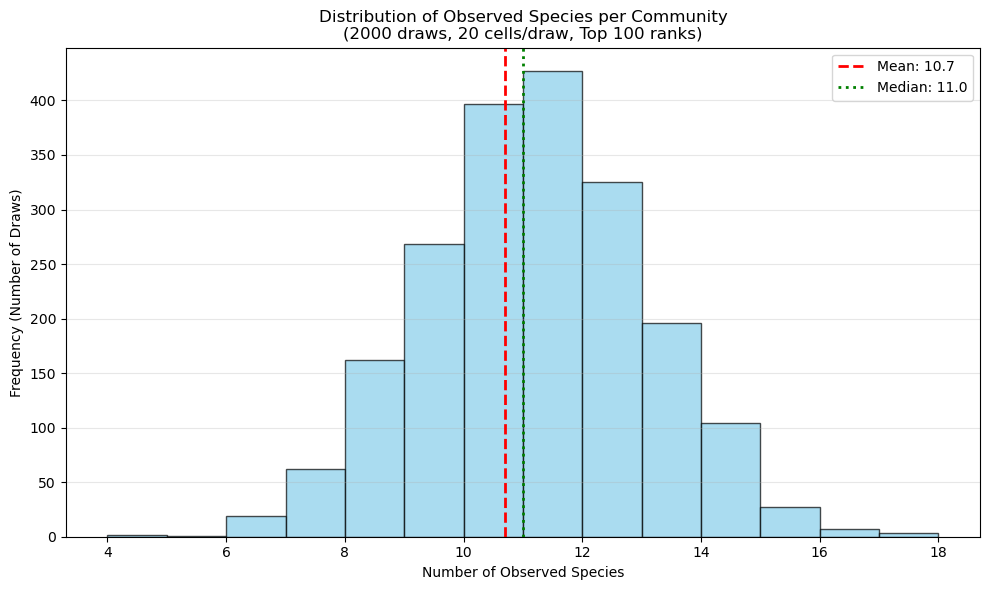

Simulation complete.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuration
FILE_1 = "Ezzeline et al 2020.csv"
COL_1 = "counts"
FILE_2 = "Bias_Leman_16S.csv"
COL_2 = "LemanWC16"
TOP_N = 100

# User inputs for simulation
CELLS_PER_COMMUNITY = 20  # Total reads/cells per simulated community
N_DRAWS = 2000                # Number of communities to simulate

def load_and_process_data(file_path, column_name, n_ranks):
    """Loads CSV, sorts by counts, takes top N, and converts to relative abundance."""
    df = pd.read_csv(file_path, sep = ";")
    
    # Sort descending by counts and take top N
    df_sorted = df.sort_values(by=column_name, ascending=False).head(n_ranks)
    
    # Calculate relative abundance (proportion)
    total_counts = df_sorted[column_name].sum()
    rel_abundance = df_sorted[column_name] / total_counts
    
    return rel_abundance.values

def simulate_community_sampling(rel_abundance_mean, n_cells, n_draws):
    """
    Simulates n_draws communities. 
    Returns the number of observed species (non-zero counts) per draw.
    """
    observed_species = []
    
    # Multinomial distribution is ideal for sampling counts from relative abundances
    # We draw n_cells for each of the n_draws communities
    samples = np.random.multinomial(n=n_cells, pvals=rel_abundance_mean, size=n_draws)
    
    # Count how many species have > 0 counts in each draw
    for sample in samples:
        n_species = np.count_nonzero(sample)
        observed_species.append(n_species)
        
    return observed_species

# 1. Load and Process Data
print(f"Loading {FILE_1} and {FILE_2}...")
try:
    ra_1 = load_and_process_data(FILE_1, COL_1, TOP_N)
    ra_2 = load_and_process_data(FILE_2, COL_2, TOP_N)
    
    # Compute mean relative abundance across the two datasets for each rank
    mean_rel_abundance = (ra_1 + ra_2) / 2
    
    # Normalize to ensure they sum exactly to 1 (floating point safety)
    mean_rel_abundance = mean_rel_abundance / mean_rel_abundance.sum()
    
    print(f"Processed top {TOP_N} ranks. Sum of mean relative abundance: {mean_rel_abundance.sum():.5f}")

except FileNotFoundError as e:
    print(f"Error: Could not find file. {e}")
    exit()
except Exception as e:
    print(f"Error processing data: {e}")
    exit()

# 2. Run Simulation
print(f"Simulating {N_DRAWS} communities with {CELLS_PER_COMMUNITY} cells each...")
observed_counts = simulate_community_sampling(mean_rel_abundance, CELLS_PER_COMMUNITY, N_DRAWS)

# 3. Plotting Histogram
plt.figure(figsize=(10, 6))

# Create histogram
# 'bins' defines the number of bars. We use integer bins since species count is discrete.
n, bins, patches = plt.hist(observed_counts, bins=range(min(observed_counts), max(observed_counts) + 2), 
                            edgecolor='black', alpha=0.7, color='skyblue')

# Add statistics
mean_val = np.mean(observed_counts)
median_val = np.median(observed_counts)

plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='dotted', linewidth=2, label=f'Median: {median_val:.1f}')

plt.title(f'Distribution of Observed Species per Community\n({N_DRAWS} draws, {CELLS_PER_COMMUNITY} cells/draw, Top {TOP_N} ranks)')
plt.xlabel('Number of Observed Species')
plt.ylabel('Frequency (Number of Draws)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Simulation complete.")

## saturation curves

Running simulation for k=1 to 100 with 1000 draws each...


  Completed k=20
  Completed k=40
  Completed k=60
  Completed k=80
  Completed k=100


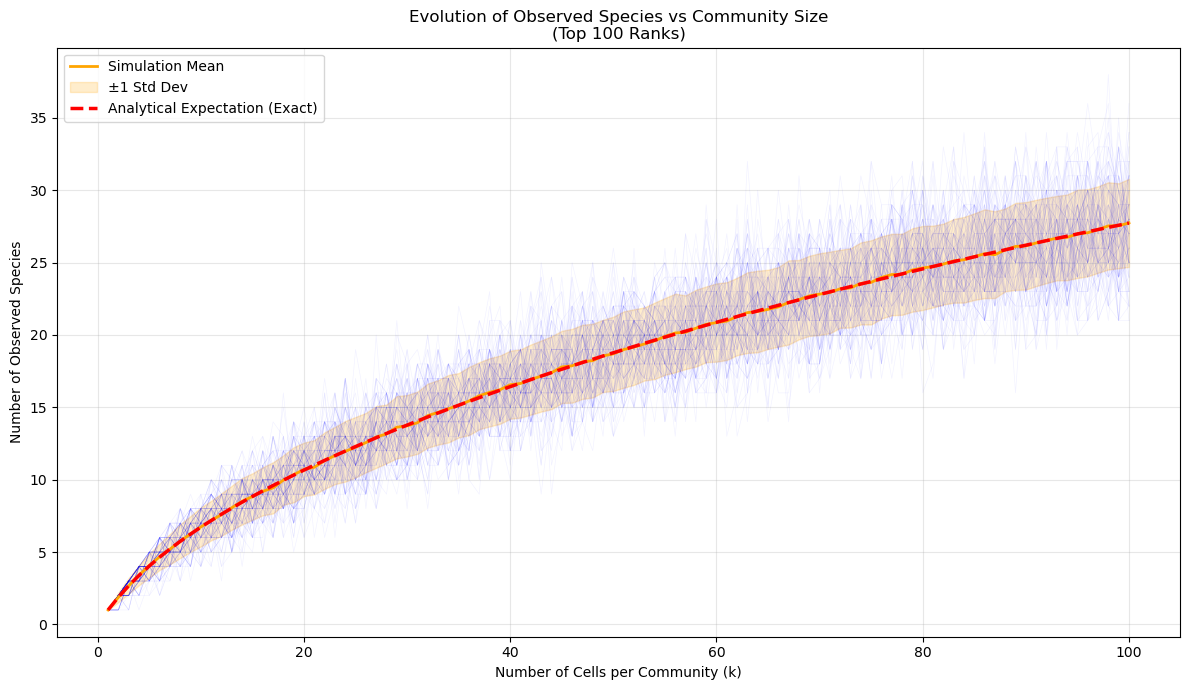

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
FILE_1 = "Ezzeline et al 2020.csv"
COL_1 = "counts"
FILE_2 = "Bias_Leman_16S.csv"
COL_2 = "LemanWC16"
TOP_N = 100

MAX_CELLS = 100       # Range 1 to 100
N_DRAWS = 1000        # 1000 draws per cell count
# =================================================

def load_and_average_data(file1, col1, file2, col2, top_n):
    """Loads and prepares mean relative abundance."""
    def process_file(path, col):
        df = pd.read_csv(path, sep = ';')
        df_sorted = df.sort_values(by=col, ascending=False).head(top_n)
        total = df_sorted[col].sum()
        return (df_sorted[col] / total).values

    ra1 = process_file(file1, col1)
    ra2 = process_file(file2, col2)
    mean_ra = (ra1 + ra2) / 2
    return mean_ra / mean_ra.sum()

def calculate_expected_saturation(mean_rel_abundance, max_cells):
    """
    ANALYTICAL APPROACH (Fastest)
    Calculates the exact expected number of species for k=1 to max_cells.
    Formula: E[S_k] = Sum(1 - (1 - p_i)^k) for all species i.
    
    Returns:
        k_values: array of cell counts (1 to max_cells)
        expected_species: array of mean species counts
    """
    k_values = np.arange(1, max_cells + 1)
    p = mean_rel_abundance
    
    # Vectorized calculation: 
    # Create a matrix where rows are species, cols are k values
    # Compute (1 - p)^k for all k at once
    # Shape: (n_species, max_cells)
    prob_missing = (1 - p[:, np.newaxis]) ** k_values
    
    # Expected species present = 1 - prob_missing, summed over all species
    expected_species = np.sum(1 - prob_missing, axis=0)
    
    return k_values, expected_species

def simulate_saturation_variance(mean_rel_abundance, max_cells, n_draws):
    """
    SIMULATION APPROACH (Optimized)
    Simulates n_draws for EACH cell count k to show variance.
    Uses vectorized multinomial sampling and cumulative logic.
    
    Returns:
        k_values: array of cell counts
        simulation_results: 2D array (max_cells, n_draws) with species counts
    """
    k_values = np.arange(1, max_cells + 1)
    n_species = len(mean_rel_abundance)
    
    # Store results: Rows = cell count (k), Cols = draw index
    results = np.zeros((max_cells, n_draws), dtype=int)
    
    print(f"Running simulation for k=1 to {max_cells} with {n_draws} draws each...")
    
    # We iterate over k because the total 'n' in multinomial changes.
    # However, we can vectorize the 'n_draws' part.
    for i, k in enumerate(k_values):
        # Sample all n_draws at once for this specific k
        # Shape: (n_draws, n_species)
        samples = np.random.multinomial(n=k, pvals=mean_rel_abundance, size=n_draws)
        
        # Count non-zero entries for each draw
        # Axis 1 collapses the species dimension
        results[i] = np.count_nonzero(samples, axis=1)
        
        if (i + 1) % 20 == 0:
            print(f"  Completed k={k}")
            
    return k_values, results

def plot_diversity_evolution(k_values, expected_mean=None, sim_data=None):
    """
    Plots the evolution of diversity.
    - If expected_mean is provided: Plots the smooth analytical curve.
    - If sim_data is provided: Plots the scatter of draws + mean.
    """
    plt.figure(figsize=(12, 7))
    
    if sim_data is not None:
        # sim_data shape: (max_cells, n_draws)
        # Plot a subset of draws for visualization (otherwise too dense)
        subset_size = min(100, sim_data.shape[1])
        subset_indices = np.random.choice(sim_data.shape[1], subset_size, replace=False)
        
        for idx in subset_indices:
            plt.plot(k_values, sim_data[:, idx], alpha=0.05, color='blue', linewidth=0.5)
        
        # Plot simulation mean
        sim_mean = np.mean(sim_data, axis=1)
        plt.plot(k_values, sim_mean, color='orange', linewidth=2, label='Simulation Mean')
        
        # Plot variance shading (Std Dev)
        sim_std = np.std(sim_data, axis=1)
        plt.fill_between(k_values, sim_mean - sim_std, sim_mean + sim_std, 
                         color='orange', alpha=0.2, label='±1 Std Dev')

    if expected_mean is not None:
        plt.plot(k_values, expected_mean, color='red', linestyle='--', linewidth=2.5, 
                 label='Analytical Expectation (Exact)')
    
    plt.title(f'Evolution of Observed Species vs Community Size\n(Top {TOP_N} Ranks)')
    plt.xlabel('Number of Cells per Community (k)')
    plt.ylabel('Number of Observed Species')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ================= EXECUTION =================

# 1. Load Data
mean_ra = load_and_average_data(FILE_1, COL_1, FILE_2, COL_2, TOP_N)

# 2. Calculate Analytical Expectation (Instant, No Noise)
k_vals, expected_curve = calculate_expected_saturation(mean_ra, MAX_CELLS)

# 3. Run Simulation (Optional: for variance visualization)
# This is now efficient because we vectorize the draws per k, 
# and k is small (1-100). Total ops: 100 * 1000 = 100k multinomials. Very fast.
k_vals_sim, sim_results = simulate_saturation_variance(mean_ra, MAX_CELLS, N_DRAWS)

# 4. Plot
plot_diversity_evolution(k_vals, expected_mean=expected_curve, sim_data=sim_results)

Bien, ça reste dans les même ordres de grandeur que ce qu'on a fait jusqu'à maintenant, c'est une bonne nouvelle ! Je voudrais juste confirmer que rester à 10-20 cell par sub-community permet d'avoir une bonne variabilité entre les sub-comm.

Let's try to give it the same layout than the other graphs...

Loading data...
Running simulation for k=1 to 30 (1000 draws each)...
  Completed k=20
  Completed k=30


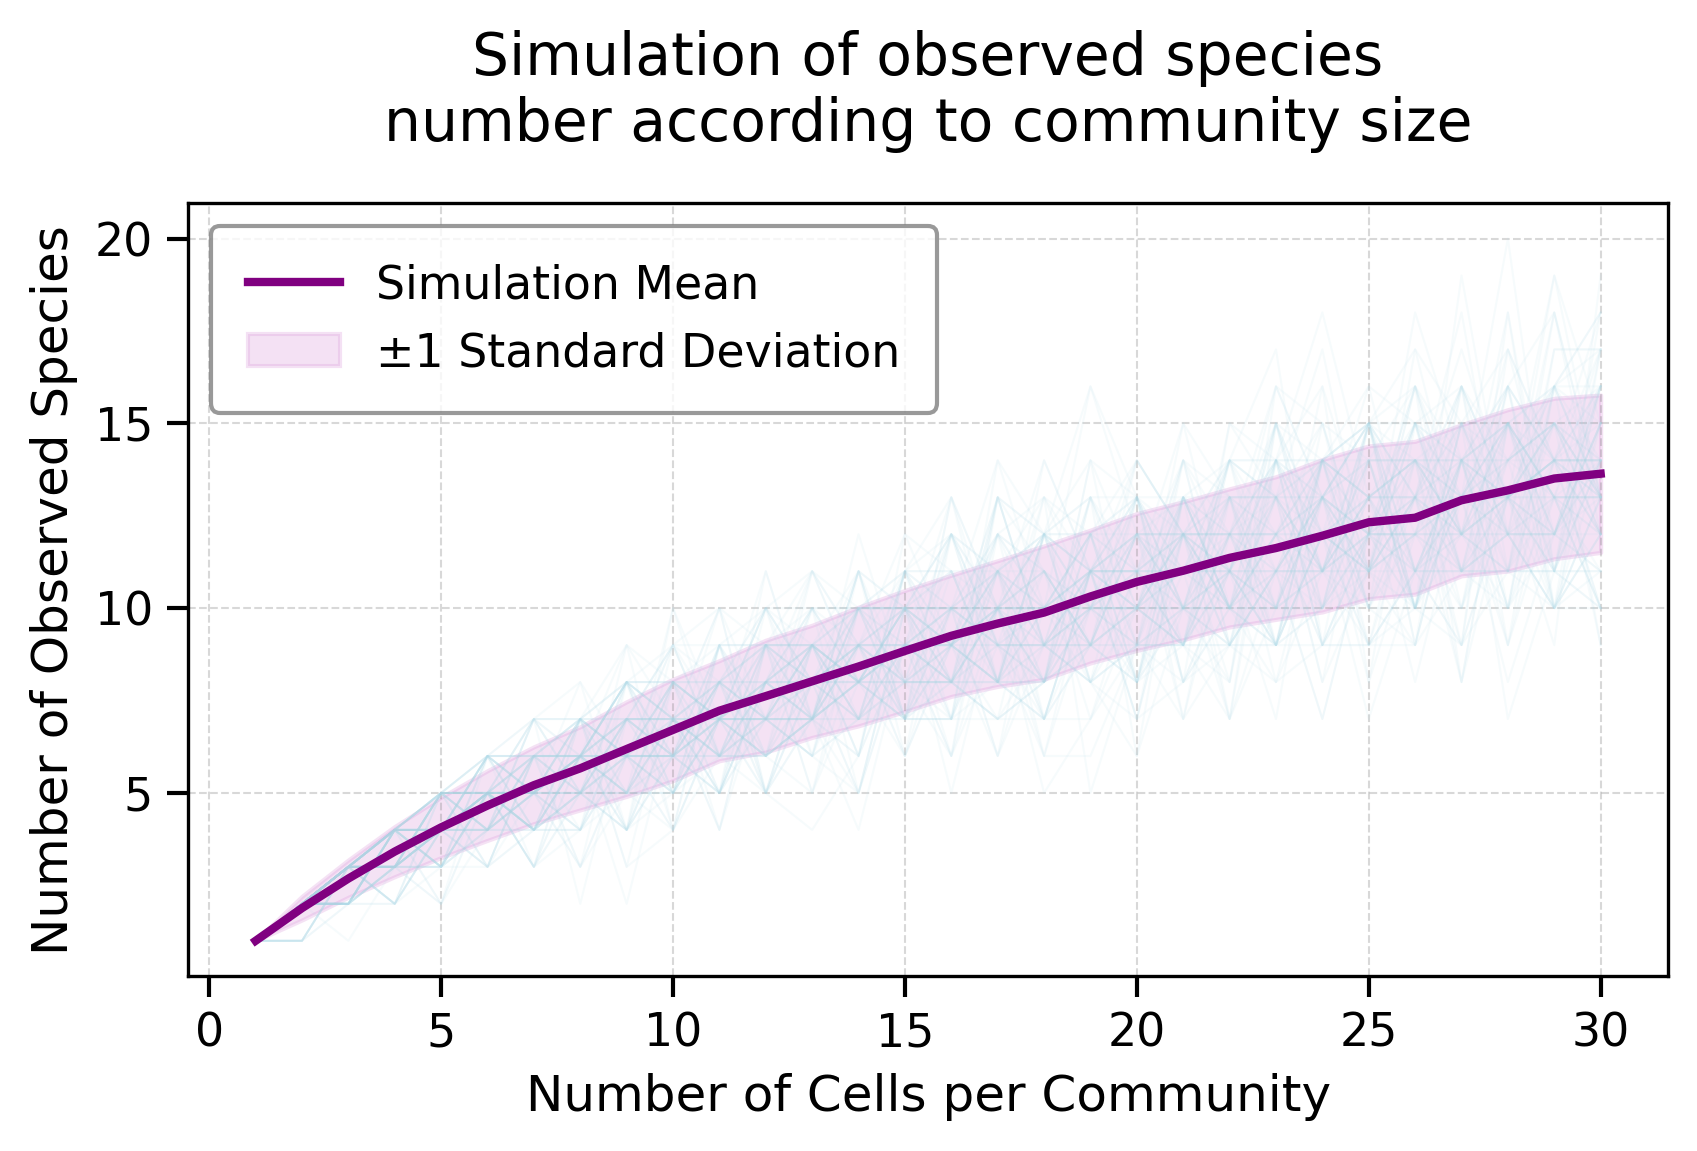

Process finished successfully.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
# Data Files
FILE_1 = "Ezzeline et al 2020.csv"
COL_1 = "counts"
FILE_2 = "Bias_Leman_16S.csv"
COL_2 = "LemanWC16"

# Analysis Parameters
TOP_N = 100           # Number of top ranks to analyze
MAX_CELLS = 30       # X-axis range (1 to 100 cells)
N_DRAWS = 1000        # Number of simulations per cell count

# Plotting Layout (Matching your report style)
plot_width_cm = 15
plot_height_cm = 10
dpi = 300
# =================================================

def load_and_average_data(file1, col1, file2, col2, top_n):
    """Loads and prepares mean relative abundance."""
    def process_file(path, col):
        try:
            df = pd.read_csv(path, sep = ";")
            if col not in df.columns:
                raise ValueError(f"Column '{col}' not found in {path}.")
            df_sorted = df.sort_values(by=col, ascending=False).head(top_n)
            total = df_sorted[col].sum()
            if total == 0: raise ValueError("Total counts zero.")
            return (df_sorted[col] / total).values
        except FileNotFoundError:
            print(f"CRITICAL ERROR: File '{path}' not found.")
            raise

    print("Loading data...")
    ra1 = process_file(file1, col1)
    ra2 = process_file(file2, col2)
    mean_ra = (ra1 + ra2) / 2
    return mean_ra / mean_ra.sum()

def calculate_expected_saturation(mean_rel_abundance, max_cells):
    """Calculates exact expected number of species (Analytical)."""
    k_values = np.arange(1, max_cells + 1)
    p = mean_rel_abundance
    prob_missing = (1 - p[:, np.newaxis]) ** k_values
    expected_species = np.sum(1 - prob_missing, axis=0)
    return k_values, expected_species

def simulate_saturation_variance(mean_rel_abundance, max_cells, n_draws):
    """Simulates n_draws for EACH cell count k to show variance."""
    k_values = np.arange(1, max_cells + 1)
    results = np.zeros((max_cells, n_draws), dtype=int)
    
    print(f"Running simulation for k=1 to {max_cells} ({n_draws} draws each)...")
    for i, k in enumerate(k_values):
        samples = np.random.multinomial(n=k, pvals=mean_rel_abundance, size=n_draws)
        results[i] = np.count_nonzero(samples, axis=1)
        if (i + 1) % 20 == 0 or i == max_cells - 1:
            print(f"  Completed k={k}")
    return k_values, results

def plot_diversity_evolution_styled(k_values, expected_mean=None, sim_data=None):
    """
    Plots the evolution of diversity using the specific report layout style.
    """
    # 1. Setup Figure Dimensions
    fig_width_in = plot_width_cm / 2.54
    fig_height_in = plot_height_cm / 2.54
    
    fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), dpi=dpi)
    
    # 2. Plot Simulation Data (if available)
    if sim_data is not None:
        # Subset of individual draws (faint lines)
        subset_size = min(100, sim_data.shape[1])
        subset_indices = np.random.choice(sim_data.shape[1], subset_size, replace=False)
        
        for idx in subset_indices:
            ax.plot(k_values, sim_data[:, idx], color='lightblue', linewidth=0.5, alpha=0.1, label='_nolegend_')
        
        # Simulation Mean
        sim_mean = np.mean(sim_data, axis=1)
        ax.plot(k_values, sim_mean, color='purple', linewidth=2, label='Simulation Mean')
        
        # Variance Shading (Std Dev)
        sim_std = np.std(sim_data, axis=1)
        ax.fill_between(k_values, sim_mean - sim_std, sim_mean + sim_std, 
                        color='plum', alpha=0.3, label='±1 Standard Deviation')

    ## 3. Plot Analytical Expectation
    #if expected_mean is not None:
    #    ax.plot(k_values, expected_mean, color='red', linestyle='--', linewidth=2, 
     #           label='Analytical Expectation')

    # 4. Apply Report Styling
    # Title & Labels
    ax.set_title(f'Simulation of observed species\nnumber according to community size', 
                 fontsize=14, fontweight='normal', pad=15)
    ax.set_xlabel('Number of Cells per Community', fontsize=12, fontweight='normal')
    ax.set_ylabel('Number of Observed Species', fontsize=12, fontweight='normal')
    
    # Ticks
    ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=5)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1, length=3)
    
    # Legend (Matching your specific style)
    leg = ax.legend(
        loc='best',
        prop={'size': 11, 'weight': 'normal'},
        frameon=True,
        framealpha=0.8,
        edgecolor='gray',
        borderpad=0.8
    )
    leg.get_frame().set_linewidth(1.0)
    
    # Grid (Subtle, matching scientific style)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
    
    # Transparent Backgrounds
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)
    
    plt.tight_layout()
    plt.show()

# ================= EXECUTION FLOW =================

if __name__ == "__main__":
    try:
        # 1. Load Data
        mean_ra = load_and_average_data(FILE_1, COL_1, FILE_2, COL_2, TOP_N)
        
        # 2. Calculate Analytical Expectation
        k_vals, expected_curve = calculate_expected_saturation(mean_ra, MAX_CELLS)
        
        # 3. Run Simulation
        k_vals_sim, sim_results = simulate_saturation_variance(mean_ra, MAX_CELLS, N_DRAWS)
        
        # 4. Plot with Styled Layout
        plot_diversity_evolution_styled(k_vals, expected_mean=expected_curve, sim_data=sim_results)
        
        print("Process finished successfully.")

    except Exception as e:
        print(f"\n--- ERROR ---\n{e}")

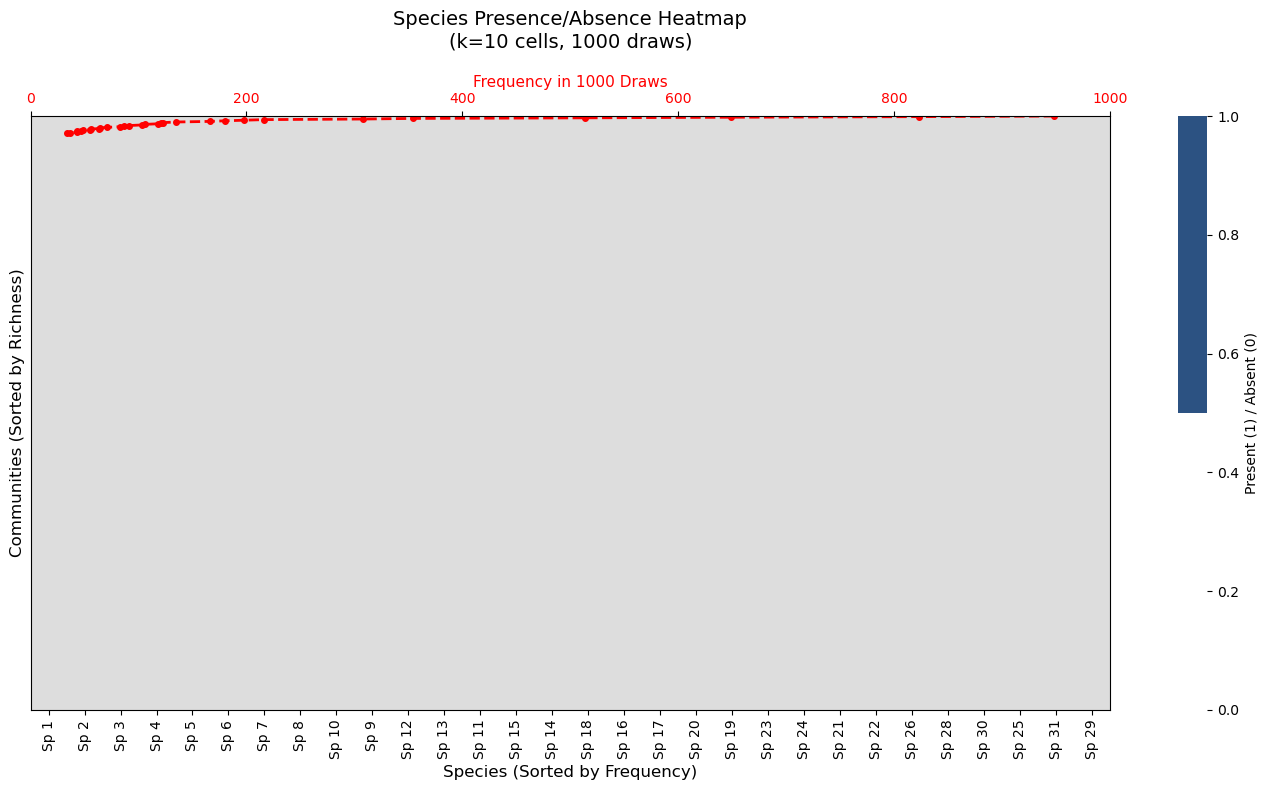

Data check: Min=0.0, Max=1.0, Unique values=[0. 1.]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_composition_heatmap(count_matrix, k_value, max_species_display=30):
    """
    Plots a robust binary heatmap.
    """
    n_draws, n_species = count_matrix.shape
    
    # 1. Convert to Presence/Absence (Binary) explicitly as float for heatmap safety
    binary_matrix = (count_matrix > 0).astype(float)
    
    # 2. Identify most frequent species
    species_frequency = np.sum(binary_matrix, axis=0)
    sorted_species_idx = np.argsort(species_frequency)[::-1]
    top_indices = sorted_species_idx[:max_species_display]
    
    # Subset matrix
    plot_matrix = binary_matrix[:, top_indices]
    
    # 3. Sort Draws (by richness)
    richness = np.sum(plot_matrix, axis=1)
    sort_order = np.lexsort((plot_matrix[:, 0], richness)) # Sort by richness, then top species
    final_matrix = plot_matrix[sort_order]
    
    # 4. Plotting with Explicit Controls
    plt.figure(figsize=(14, 8))
    
    # Define a custom discrete colormap: White for 0, Blue for 1
    # This avoids gradient interpolation issues
    colors = ["#FFFFFF", "#2C5282"] # White, Dark Blue
    cmap = plt.matplotlib.colors.ListedColormap(colors)
    
    # Draw the heatmap
    # vmin=0, vmax=1 forces the scale to strictly map 0->White and 1->Blue
    sns.heatmap(
        final_matrix,
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar_kws={'label': 'Present (1) / Absent (0)'},
        xticklabels=[f"Sp {i+1}" for i in top_indices],
        yticklabels=False,
        linewidths=0.5,      # Thicker lines to separate cells
        linecolor='#dddddd'  # Light grey lines
    )
    
    plt.title(f'Species Presence/Absence Heatmap\n(k={k_value} cells, {n_draws} draws)', 
              fontsize=14, pad=20)
    plt.xlabel('Species (Sorted by Frequency)', fontsize=12)
    plt.ylabel(f'Communities (Sorted by Richness)', fontsize=12)
    
    # Add Frequency Line on Top
    ax = plt.gca()
    ax2 = ax.twiny()
    freqs = species_frequency[top_indices]
    ax2.plot(freqs, range(len(top_indices)), color='red', linestyle='--', linewidth=2, marker='o', markersize=4)
    ax2.set_xlabel('Frequency in 1000 Draws', color='red', fontsize=11)
    ax2.tick_params(axis='x', labelcolor='red')
    ax2.set_xlim(0, n_draws)
    
    plt.tight_layout()
    plt.show()
    
    # Debug print to verify data
    print(f"Data check: Min={final_matrix.min()}, Max={final_matrix.max()}, Unique values={np.unique(final_matrix)}")

# ==========================================================
# EXECUTION
# ==========================================================

# Ensure you have mean_ra defined from your previous steps!
# If not, uncomment the loading block from the previous script.

K_TARGET = 10
N_DRAWS = 1000

# Re-generate data for safety
if 'mean_ra' not in globals():
    print("ERROR: 'mean_ra' not found. Please run the data loading step first.")
else:
    sim_data = np.random.multinomial(n=K_TARGET, pvals=mean_ra, size=N_DRAWS)
    plot_composition_heatmap(sim_data, k_value=K_TARGET)